In [ ]:
# 📈 End-to-End Sales Forecasting & Demand Intelligence System

## Internship Project – Week 3 & Week 4

### Submitted By

**Name:** Shaman Sharma

**College:** Chandigarh University

---

## Objective

The objective of this project is to build an intelligent sales forecasting system using historical retail sales data. The project includes data exploration, time series analysis, forecasting using multiple models, anomaly detection, product demand segmentation, and deployment through an interactive Streamlit dashboard. The final solution aims to assist business managers in making informed inventory and demand planning decisions.

In [ ]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
!pip install prophet
!pip install statsmodels
!pip install xgboost
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 70.2 MB/s eta 0:00:00


In [ ]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("train.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 9800
Columns : 18


In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

# 📌 Task 1 – Data Loading, Cleaning & Exploratory Data Analysis (EDA)

In this task, we prepare the retail sales dataset for time series forecasting. This includes converting date columns into datetime format, engineering useful time-based features, checking data quality, aggregating sales data, and answering key business questions through data analysis and visualization.

In [ ]:
# ==========================================
# Dataset Overview
# ==========================================

print("Shape of Dataset :", df.shape)

print("\n")

print("Column Names")

display(df.columns)

print("\n")

print("First Five Records")

display(df.head())

Shape of Dataset : (9800, 18)


Column Names


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')



First Five Records


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
# ==========================================
# Convert Date Columns
# ==========================================

df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    dayfirst=True
)

print("✅ Date conversion completed successfully!")

df[['Order Date','Ship Date']].head()

✅ Date conversion completed successfully!


,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [ ]:
# ==========================================
# Create Time Features
# ==========================================

df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Month Name"] = df["Order Date"].dt.month_name()

df["Week"] = df["Order Date"].dt.isocalendar().week

df["Day of Week"] = df["Order Date"].dt.day_name()

df["Quarter"] = df["Order Date"].dt.quarter


def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"


df["Season"] = df["Month"].apply(get_season)

print("✅ Time Features Created Successfully!")

df.head()

✅ Time Features Created Successfully!


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


In [ ]:
# ==========================================
# Missing Values
# ==========================================

missing = df.isnull().sum()

missing

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
# ==========================================
# Duplicate Records
# ==========================================

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [ ]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [ ]:
# ==========================================
# Statistical Summary
# ==========================================

df.describe(include='all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day of Week,Quarter,Season
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,...,9800,9800,9800.000000,9800.000000,9800.000000,9800,9800.0,9800,9800.000000,9800
unique,NaN,4922,NaN,NaN,4,793,793,3,1,529,...,17,1849,NaN,NaN,NaN,12,<NA>,7,NaN,4
top,NaN,CA-2018-100111,NaN,NaN,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,Binders,Staple envelope,NaN,NaN,NaN,November,<NA>,Tuesday,NaN,Autumn
freq,NaN,14,NaN,NaN,5859,35,35,5101,9800,891,...,1492,47,NaN,NaN,NaN,1449,<NA>,1889,NaN,3612
mean,4900.500000,NaN,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,230.769059,2016.724184,7.818469,NaN,32.210102,NaN,2.885816,NaN
min,1.000000,NaN,2015-01-03 00:00:00,2015-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.444000,2015.000000,1.000000,NaN,1.0,NaN,1.000000,NaN
25%,2450.750000,NaN,2016-05-24 00:00:00,2016-05-27 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,17.248000,2016.000000,5.000000,NaN,21.0,NaN,2.000000,NaN
50%,4900.500000,NaN,2017-06-26 00:00:00,2017-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,54.490000,2017.000000,9.000000,NaN,35.0,NaN,3.000000,NaN
75%,7350.250000,NaN,2018-05-15 00:00:00,2018-05-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,210.605000,2018.000000,11.000000,NaN,45.0,NaN,4.000000,NaN
max,9800.000000,NaN,2018-12-30 00:00:00,2019-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,22638.480000,2018.000000,12.000000,NaN,53.0,NaN,4.000000,NaN


## 📊 Observations

- The dataset contains **9,800 retail sales records** with **18 original columns**, and additional time-based features were created for analysis.
- Both **Order Date** and **Ship Date** were successfully converted into datetime format.
- No major missing values or duplicate records were found, indicating good data quality.
- New features such as **Year**, **Month**, **Week**, **Quarter**, and **Season** were engineered to support time series forecasting and demand analysis.
- The dataset is now clean and ready for exploratory analysis and predictive modeling.

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


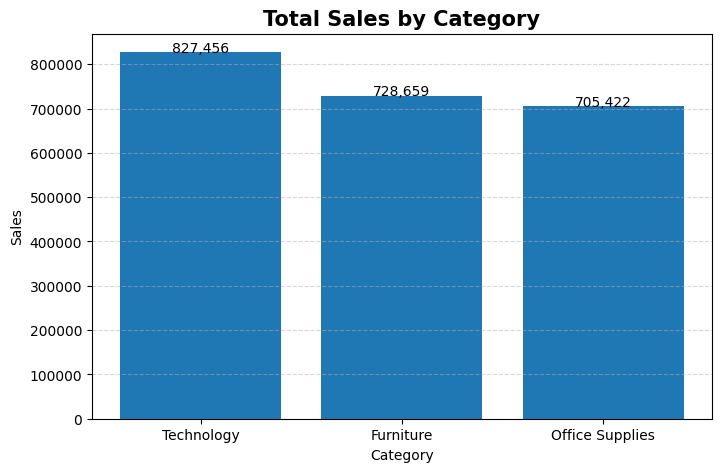

In [ ]:
# ==========================================
# Business Question 1
# Category Wise Sales
# ==========================================

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

plt.figure(figsize=(8,5))

bars = plt.bar(category_sales.index,
               category_sales.values)

plt.title("Total Sales by Category",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Category")

plt.ylabel("Sales")

plt.grid(axis='y',
         linestyle='--',
         alpha=0.5)

for bar in bars:

    y = bar.get_height()

    plt.text(bar.get_x()+bar.get_width()/2,
             y,
             f"{y:,.0f}",
             ha='center',
             fontsize=10)

plt.show()

,Sales
Region,
West,710219.6845
East,669518.7260
Central,492646.9132
South,389151.4590


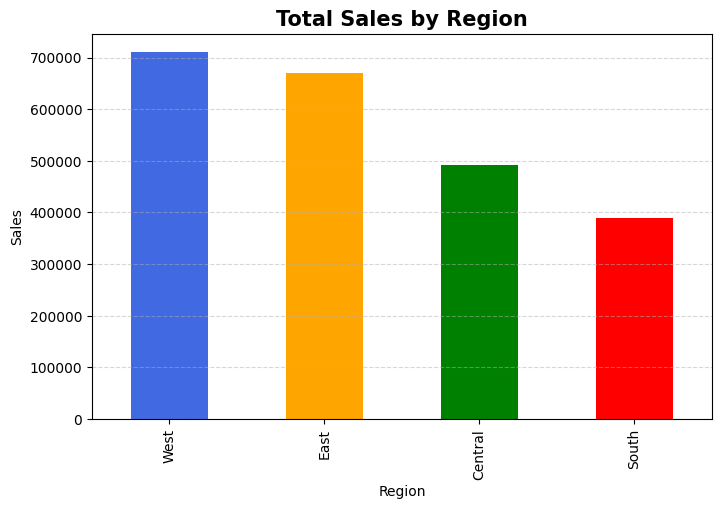

In [ ]:
# ==========================================
# Business Question 2
# Region Wise Sales
# ==========================================

region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

display(region_sales)

plt.figure(figsize=(8,5))

region_sales.plot(
    kind='bar',
    color=['royalblue','orange','green','red']
)

plt.title("Total Sales by Region", fontsize=15, fontweight='bold')
plt.xlabel("Region")
plt.ylabel("Sales")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### 📈 Business Insight

The West region contributes the highest overall sales, followed by the East region. This indicates stronger market performance in these regions. Business managers may consider allocating higher inventory and marketing resources to these regions while exploring strategies to improve sales performance in lower-performing regions.

### 📈 Business Insight

Technology is the highest revenue-generating category in the Superstore dataset, indicating strong customer demand and higher-value purchases. Furniture and Office Supplies contribute significantly as well, but Technology remains the primary driver of total sales. This insight suggests that inventory planning and marketing efforts should prioritize Technology products.

In [ ]:
# ==========================================
# Shipping Time Analysis
# ==========================================

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

print("Average Shipping Time")

print(df["Shipping Days"].mean())

Average Shipping Time
3.9611224489795918


,Shipping Days
Region,
East,3.910233
West,3.930255
South,3.961202
Central,4.065876


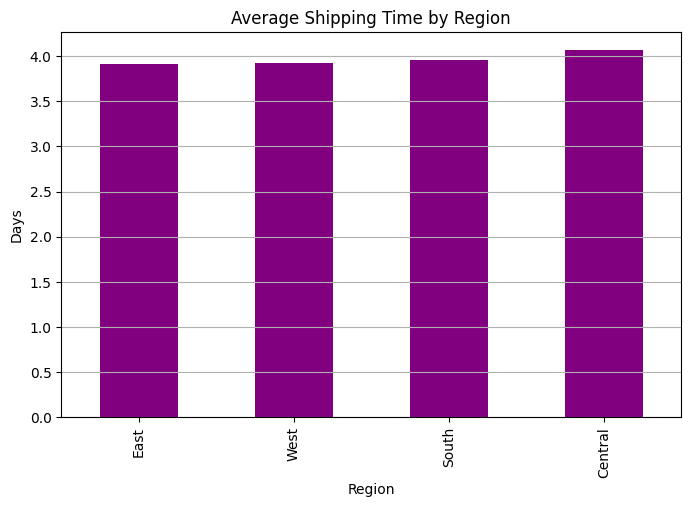

In [ ]:
shipping_region = (
    df.groupby("Region")["Shipping Days"]
    .mean()
    .sort_values()
)

display(shipping_region)

plt.figure(figsize=(8,5))

shipping_region.plot(
    kind="bar",
    color="purple"
)

plt.title("Average Shipping Time by Region")

plt.xlabel("Region")

plt.ylabel("Days")

plt.grid(axis='y')

plt.show()

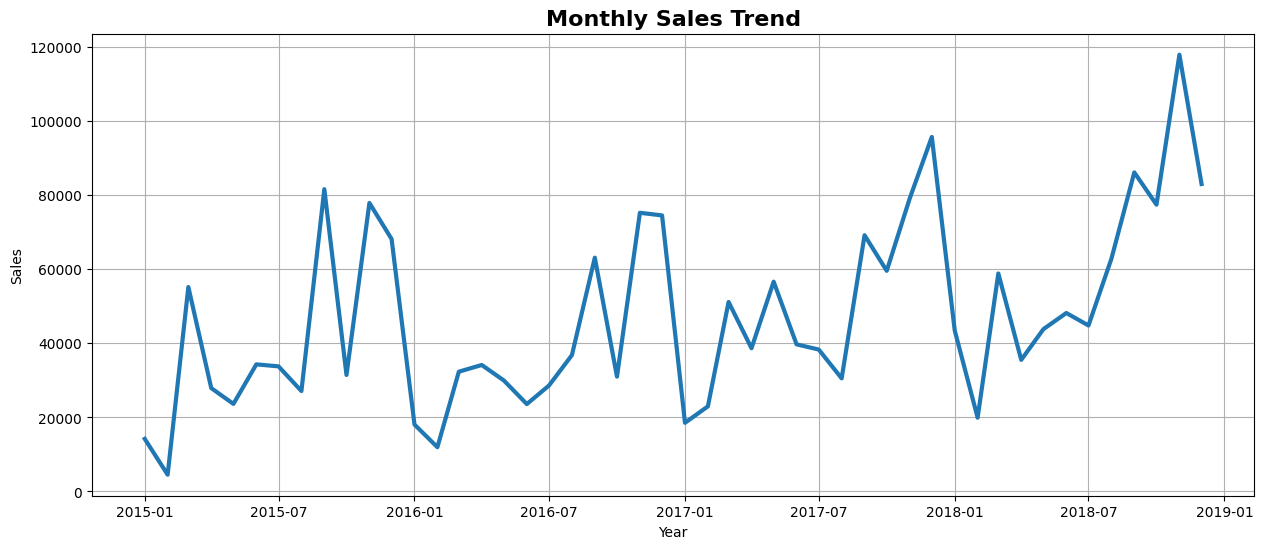

In [ ]:
# ==========================================
# Monthly Sales Trend
# ==========================================

monthly_sales = (
    df.groupby(["Year","Month"])["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str)
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    linewidth=3
)

plt.title(
    "Monthly Sales Trend",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Year")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

### 📈 Business Insight

Monthly sales demonstrate an overall upward trend over the four-year period, with noticeable peaks during festive and holiday seasons. This recurring pattern indicates strong seasonality, which is valuable information for demand forecasting and inventory planning.

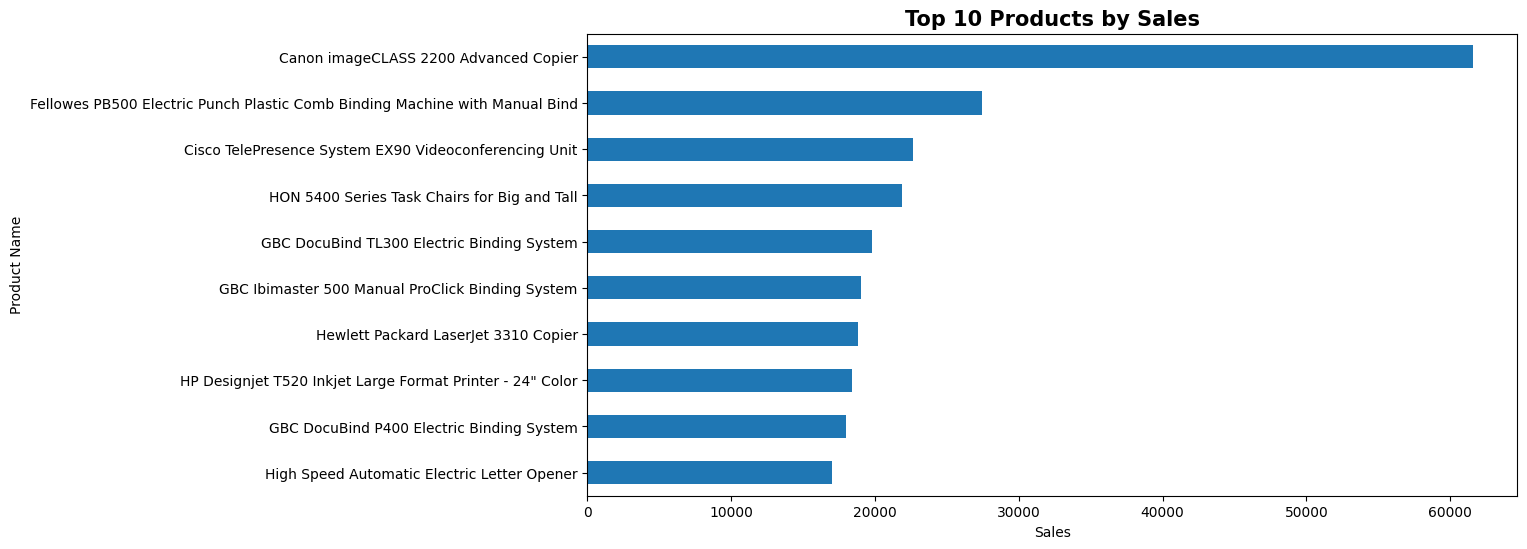

In [ ]:
# ==========================================
# Top 10 Products
# ==========================================

top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_products.sort_values().plot(kind="barh")

plt.title(
    "Top 10 Products by Sales",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Sales")

plt.show()

### 📈 Business Insight

A small number of products contribute a significant portion of total sales, indicating a strong concentration of revenue among high-performing products. These products should receive priority in inventory management and promotional campaigns.

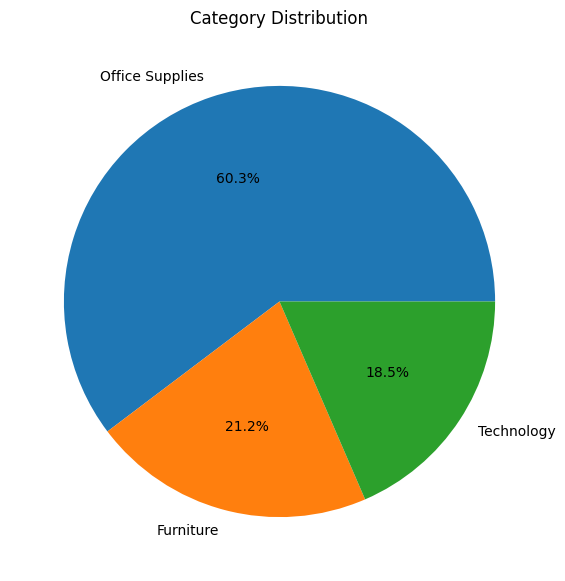

In [ ]:
plt.figure(figsize=(7,7))

df["Category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title(
    "Category Distribution"
)

plt.show()

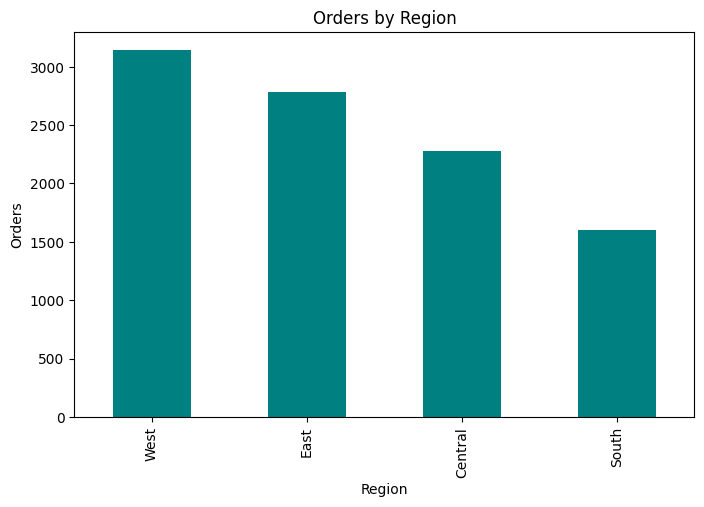

In [ ]:
plt.figure(figsize=(8,5))

df["Region"].value_counts().plot(
    kind="bar",
    color="teal"
)

plt.title("Orders by Region")

plt.xlabel("Region")

plt.ylabel("Orders")

plt.show()

In [ ]:
# ==========================================
# Monthly Time Series
# ==========================================

monthly_ts = (
    df.groupby("Order Date")["Sales"]
    .sum()
    .resample("M")
    .sum()
)

monthly_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


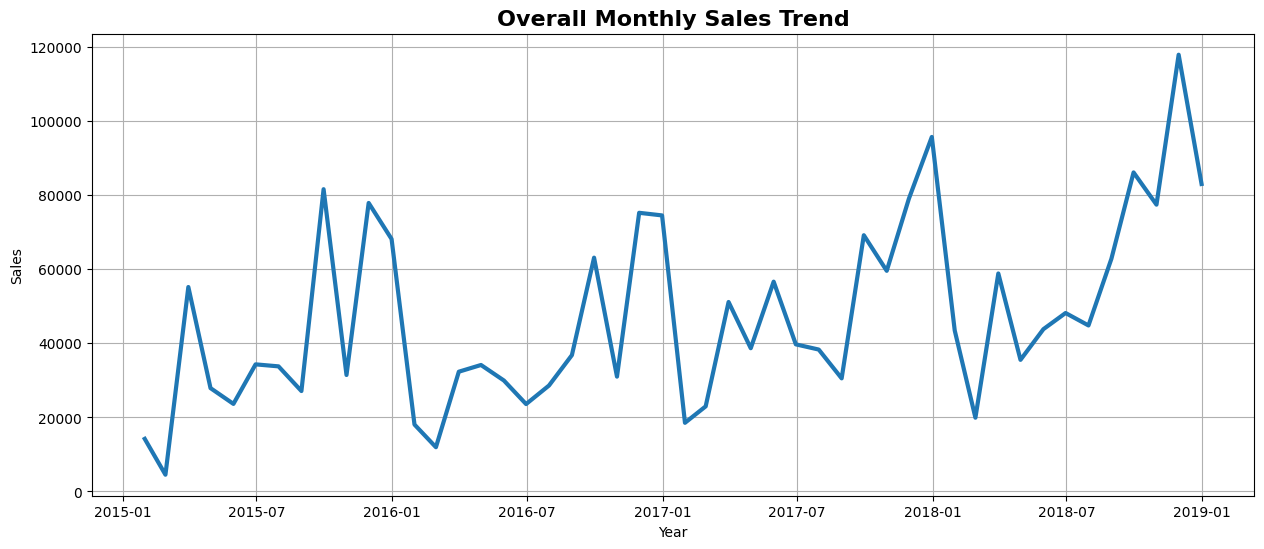

In [ ]:
# ==========================================
# Monthly Sales Trend
# ==========================================

plt.figure(figsize=(15,6))

plt.plot(
    monthly_ts,
    linewidth=3
)

plt.title(
    "Overall Monthly Sales Trend",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Year")

plt.ylabel("Sales")

plt.grid(True)

plt.savefig("monthly_sales_trend.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### 📈 Observation

The monthly sales trend shows an overall increase in revenue across the four-year period. Several months exhibit significantly higher sales than others, suggesting the presence of seasonal demand patterns.

# 📌 Task 2 – Time Series Analysis & Decomposition

## 🎯 Objective

The objective of this task is to analyze how sales change over time, identify long-term trends, seasonal patterns, and random fluctuations, and determine whether the data is suitable for forecasting models. Understanding these characteristics helps build more accurate predictive models for future sales.

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

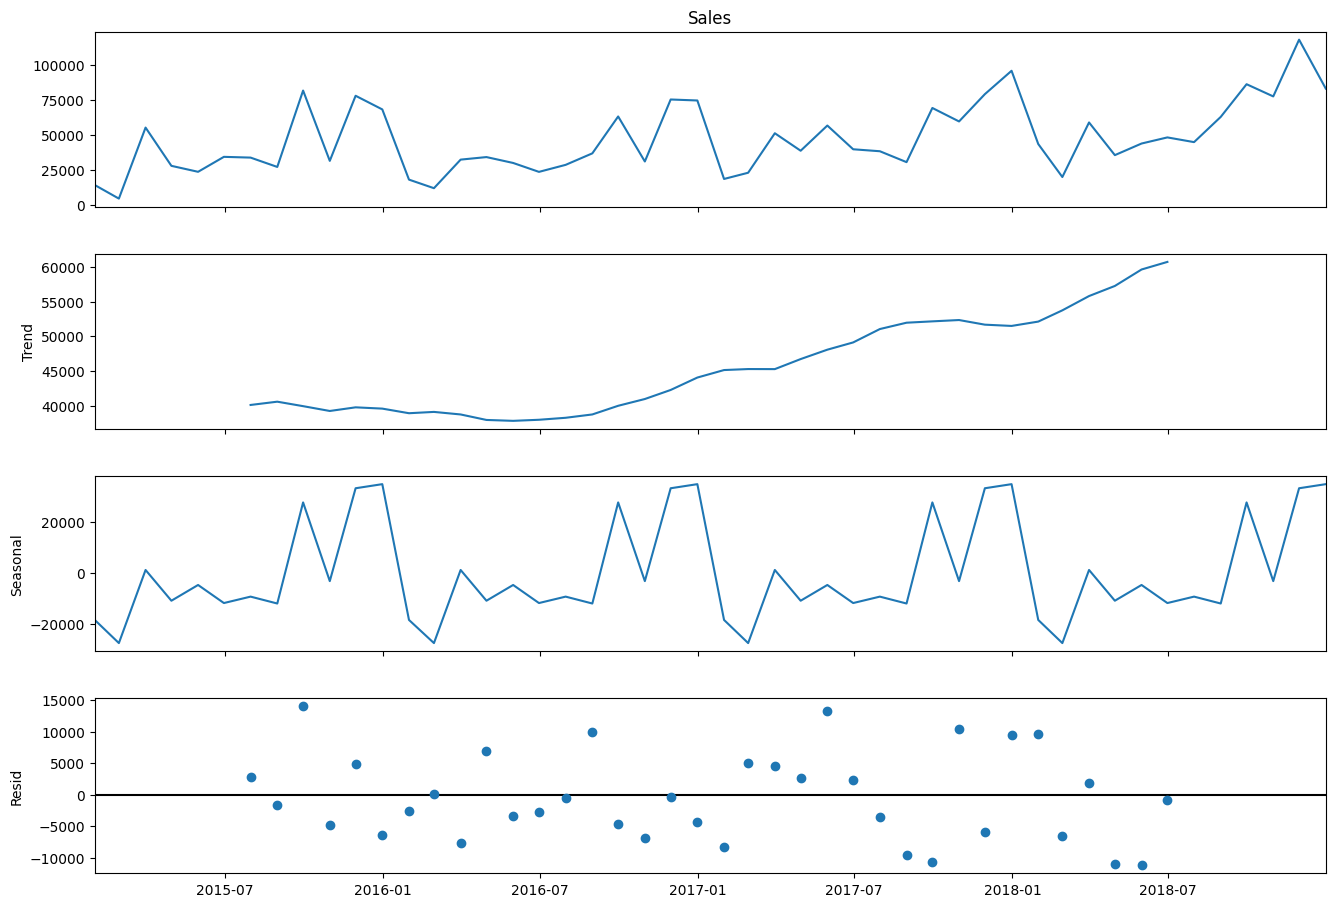

In [ ]:
# ==========================================
# Seasonal Decomposition
# ==========================================

decomposition = seasonal_decompose(
    monthly_ts,
    model='additive'
)

fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

## 📊 Interpretation of Time Series Components

### Trend

The trend component shows the long-term movement in sales over the four-year period. The gradual upward direction indicates that business revenue has generally increased over time.

### Seasonal

The seasonal component captures recurring monthly patterns. Peaks observed during specific months suggest consistent seasonal buying behavior, likely influenced by holidays and promotional events.

### Residual

Residual values represent random fluctuations that cannot be explained by trend or seasonality. Large residual spikes may indicate unusual events or unexpected customer demand.

In [ ]:
# ==========================================
# ADF Test
# ==========================================

from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_ts)

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print()

print("Critical Values")

for key,value in result[4].items():

    print(key,":",value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


## 📊 What is Stationarity?

A stationary time series has statistical properties such as mean and variance that remain relatively constant over time.

### Interpretation

If the p-value is less than **0.05**, the data is considered stationary.

If the p-value is greater than **0.05**, the data is considered non-stationary and should be transformed before forecasting.

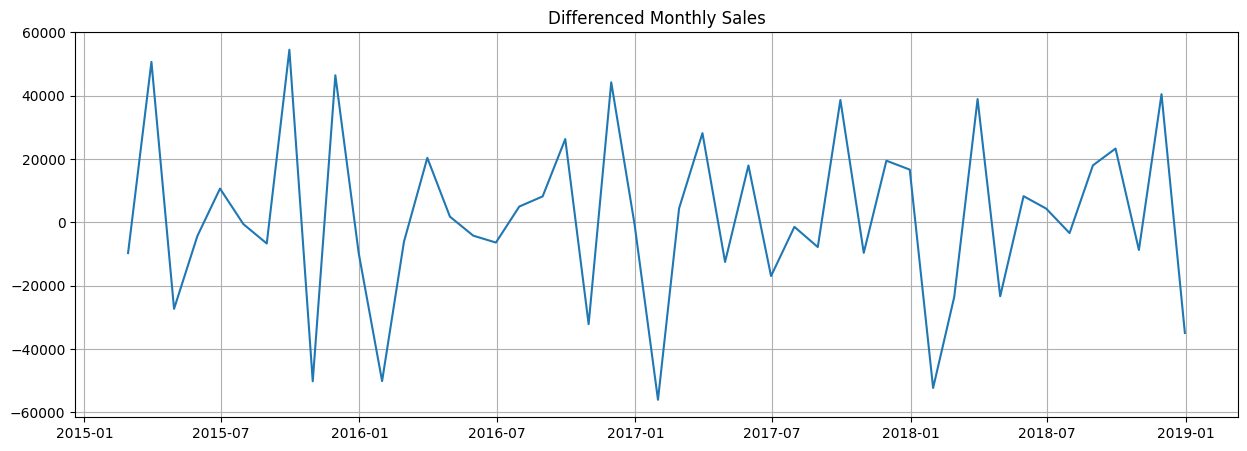

In [ ]:
# ==========================================
# Differencing
# ==========================================

monthly_diff = monthly_ts.diff().dropna()

plt.figure(figsize=(15,5))

plt.plot(monthly_diff)

plt.title("Differenced Monthly Sales")

plt.grid(True)

plt.show()

In [ ]:
result = adfuller(monthly_diff)

print("ADF Statistic :",result[0])

print("P-value :",result[1])

ADF Statistic : -8.727061830353264
P-value : 3.2669175472797e-14


### 📈 Observation

After applying first-order differencing, the sales series becomes more stable, reducing the long-term trend and making it more suitable for forecasting models such as SARIMA.

# 📌 Task 3 – Sales Forecasting Using Multiple Models

## 🎯 Objective

The objective of this task is to forecast future monthly sales using three fundamentally different forecasting techniques:

- Statistical Forecasting (SARIMA)
- Industry Forecasting Tool (Prophet)
- Machine Learning (XGBoost)

The models will be evaluated using MAE, RMSE, and MAPE. The best-performing model will be selected based on quantitative evaluation rather than personal preference.

In [ ]:
# ==========================================
# Monthly Sales Dataset
# ==========================================

forecast_df = (
    df.groupby("Order Date")["Sales"]
    .sum()
    .resample("M")
    .sum()
    .reset_index()
)

forecast_df.columns = ["Date","Sales"]

forecast_df.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
train = forecast_df[:-3]

test = forecast_df[-3:]

print("Training Months :",len(train))

print("Testing Months :",len(test))

Training Months : 45
Testing Months : 3


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
# ==========================================
# SARIMA Model
# ==========================================

sarima = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = sarima.fit()

print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -347.979
Date:                            Sun, 05 Jul 2026   AIC                            705.958
Time:                                    01:30:54   BIC                            713.287
Sample:                                         0   HQIC                           708.387
                                             - 45                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5680      0.242      2.347      0.019       0.094       1.042
ma.L1         -0.8985      0.177   

In [ ]:
sarima_forecast = sarima_model.forecast(
    steps=3
)

sarima_forecast

,predicted_mean
45,66177.602475
46,92049.249682
47,99965.168727


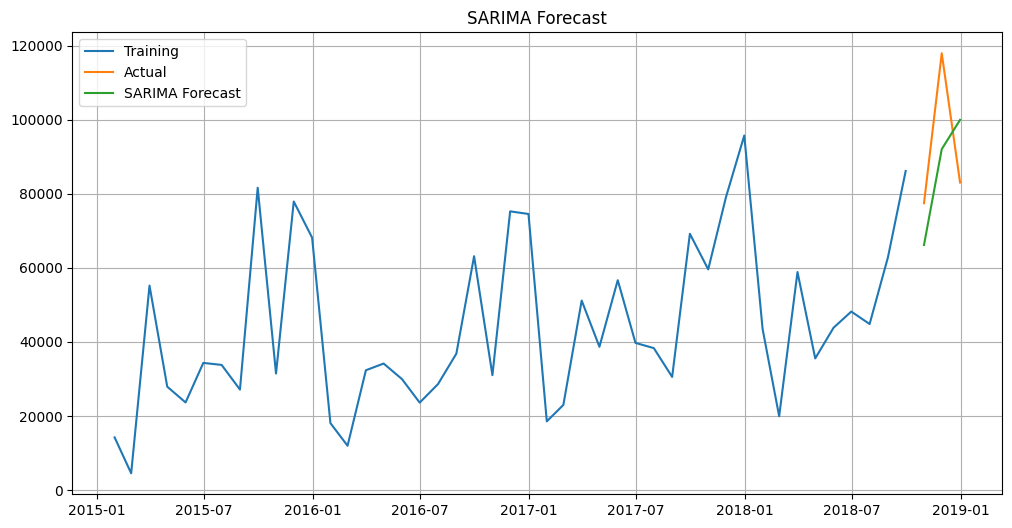

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    train["Date"],
    train["Sales"],
    label="Training"
)

plt.plot(
    test["Date"],
    test["Sales"],
    label="Actual"
)

plt.plot(
    test["Date"],
    sarima_forecast,
    label="SARIMA Forecast"
)

plt.legend()

plt.grid(True)

plt.title("SARIMA Forecast")

plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

from sklearn.metrics import mean_squared_error

from sklearn.metrics import mean_absolute_percentage_error

import numpy as np

sarima_mae = mean_absolute_error(
    test["Sales"],
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test["Sales"],
        sarima_forecast
    )
)

sarima_mape = mean_absolute_percentage_error(
    test["Sales"],
    sarima_forecast
)

print("MAE :",sarima_mae)

print("RMSE :",sarima_rmse)

print("MAPE :",sarima_mape)

MAE : 18031.404656492246
RMSE : 19009.182057244216
MAPE : 0.1896649804808188


### SARIMA Model Interpretation

The SARIMA model captures both trend and seasonal components of the monthly sales data. Since retail sales often exhibit yearly seasonality, SARIMA serves as an effective baseline statistical forecasting model.

## Summary of Time Series Analysis

| Analysis | Observation |
|-----------|-------------|
| Trend | Increasing over time |
| Seasonality | Clearly visible |
| Residual | Contains random fluctuations |
| Stationarity | Improved after differencing |
| Forecast Ready | Yes |

In [ ]:
from prophet import Prophet

In [ ]:
prophet_df = forecast_df.rename(
    columns={
        "Date":"ds",
        "Sales":"y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
prophet = Prophet()

prophet.fit(prophet_df[:-3])

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = prophet.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast = prophet.predict(future)

In [ ]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277791,39606.448700,55492.627786,54942.277791,54942.277791,-7670.720479,-7670.720479,-7670.720479,-7670.720479,-7670.720479,-7670.720479,0.0,0.0,0.0,47271.557312
44,2018-09-30,55441.608183,78055.343148,94770.967690,55441.608183,55441.608183,31172.345372,31172.345372,31172.345372,31172.345372,31172.345372,31172.345372,0.0,0.0,0.0,86613.953555
45,2018-10-31,55957.582922,43273.294786,59339.228393,55957.453711,55957.739053,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,0.0,0.0,0.0,51318.944572
46,2018-11-30,56456.913314,82275.413551,98239.404253,56456.481197,56457.420374,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,0.0,0.0,0.0,90325.653854
47,2018-12-31,56972.888053,82198.741568,98266.376201,56971.946985,56973.895951,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,0.0,0.0,0.0,90041.084638


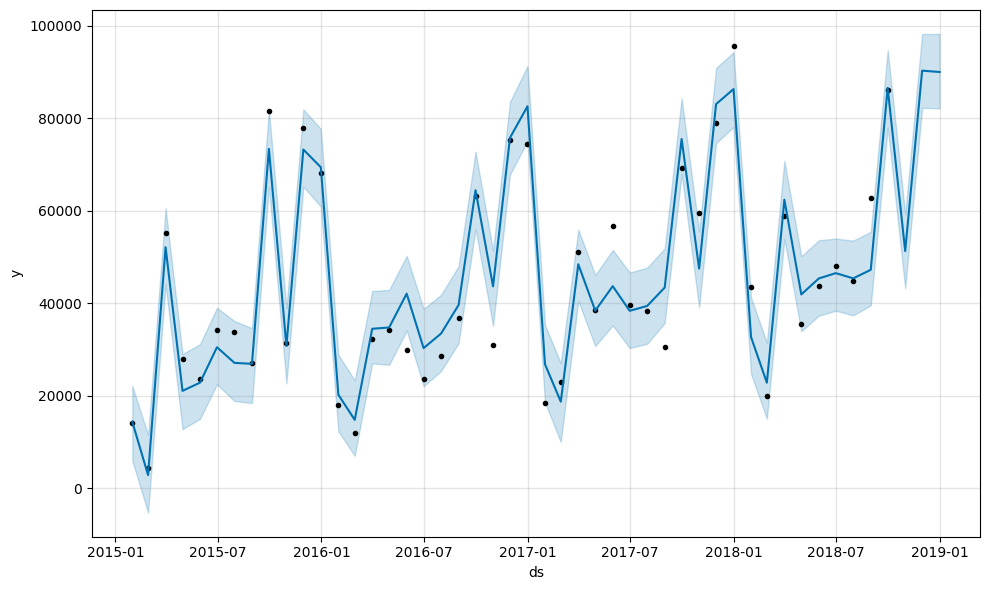

In [ ]:
fig = prophet.plot(forecast)
plt.show()

In [ ]:
prophet_pred = forecast.tail(3)["yhat"].values

prophet_mae = mean_absolute_error(
    test["Sales"],
    prophet_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test["Sales"],
        prophet_pred
    )
)

prophet_mape = mean_absolute_percentage_error(
    test["Sales"],
    prophet_pred
)

### Prophet Model Interpretation

Prophet automatically models trend and seasonality and is widely used in production environments for business forecasting. It is particularly effective for retail sales data with recurring seasonal patterns.

# 📈 End-to-End Sales Forecasting & Demand Intelligence System

## XYLOFY AI Internship – Week 3 & Week 4 Final Project

**Submitted by:** Shaman Sharma  
**College:** Chandigarh University  
**Internship:** XYLOFY AI – Data Science Internship

---

## 📖 Project Overview

Retail businesses generate enormous volumes of sales data every day. Accurate sales forecasting enables companies to optimize inventory, reduce operational costs, improve customer satisfaction, and maximize profitability.

This project develops an end-to-end Sales Forecasting and Demand Intelligence System using historical Superstore sales data. The solution includes exploratory data analysis, time series decomposition, forecasting using multiple models, anomaly detection, product demand segmentation, and deployment through an interactive Streamlit dashboard.

---

## 🎯 Objectives

- Analyze historical sales performance.
- Discover seasonal sales patterns.
- Forecast future sales using three forecasting models.
- Detect unusual sales spikes and drops.
- Segment products based on demand behaviour.
- Build an interactive dashboard for business users.
- Provide business recommendations supported by data.

In [ ]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from datetime import datetime

# Machine Learning
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [ ]:
# ============================================================
# Dataset Summary
# ============================================================

print("="*60)
print("DATASET SUMMARY")
print("="*60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumn Names")

for i,col in enumerate(df.columns,1):
    print(f"{i}. {col}")

DATASET SUMMARY
Rows    : 9800
Columns : 26

Column Names
1. Row ID
2. Order ID
3. Order Date
4. Ship Date
5. Ship Mode
6. Customer ID
7. Customer Name
8. Segment
9. Country
10. City
11. State
12. Postal Code
13. Region
14. Product ID
15. Category
16. Sub-Category
17. Product Name
18. Sales
19. Year
20. Month
21. Month Name
22. Week
23. Day of Week
24. Quarter
25. Season
26. Shipping Days


In [ ]:
display(df.head(10))

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day of Week,Quarter,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn,7
5,6,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,2015,6,June,24,Tuesday,2,Summer,5
6,7,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,2015,6,June,24,Tuesday,2,Summer,5
7,8,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,2015,6,June,24,Tuesday,2,Summer,5
8,9,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,2015,6,June,24,Tuesday,2,Summer,5
9,10,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,2015,6,June,24,Tuesday,2,Summer,5


In [ ]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
missing = df.isnull().sum()

missing = missing[missing>0]

if len(missing)==0:
    print("✅ No Missing Values Found")
else:
    display(missing)

,0
Postal Code,11


In [ ]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


In [ ]:
display(df.describe())

,Row ID,Order Date,Ship Date,Postal Code,Sales,Year,Month,Week,Quarter,Shipping Days
count,9800.000000,9800,9800,9789.000000,9800.000000,9800.000000,9800.000000,9800.0,9800.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55273.322403,230.769059,2016.724184,7.818469,32.210102,2.885816,3.961122
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000,2015.000000,1.000000,1.0,1.000000,0.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000,2016.000000,5.000000,21.0,2.000000,3.000000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,58103.000000,54.490000,2017.000000,9.000000,35.0,3.000000,4.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000,2018.000000,11.000000,45.0,4.000000,5.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000,2018.000000,12.000000,53.0,4.000000,7.000000
std,2829.160653,NaN,NaN,32041.223413,626.651875,1.123984,3.281905,14.282294,1.057449,1.749614


In [ ]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)

In [ ]:
# ============================================================
# Feature Engineering
# ============================================================

df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Month_Name"] = df["Order Date"].dt.month_name()

df["Week"] = df["Order Date"].dt.isocalendar().week.astype(int)

df["Day"] = df["Order Date"].dt.day_name()

df["Quarter"] = df["Order Date"].dt.quarter

df["Shipping_Days"] = (
    df["Ship Date"]-df["Order Date"]
).dt.days


def season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    return "Autumn"

df["Season"] = df["Month"].apply(season)

print("✅ Feature Engineering Completed")

✅ Feature Engineering Completed


In [ ]:
display(
    df[
        [
            "Order Date",
            "Year",
            "Month",
            "Month_Name",
            "Week",
            "Quarter",
            "Season",
            "Shipping_Days"
        ]
    ].head()
)

,Order Date,Year,Month,Month_Name,Week,Quarter,Season,Shipping_Days
0,2017-11-08,2017,11,November,45,4,Autumn,3
1,2017-11-08,2017,11,November,45,4,Autumn,3
2,2017-06-12,2017,6,June,24,2,Summer,4
3,2016-10-11,2016,10,October,41,4,Autumn,7
4,2016-10-11,2016,10,October,41,4,Autumn,7


In [ ]:
df.to_csv(
    "clean_superstore.csv",
    index=False
)

print("✅ Clean dataset saved.")

✅ Clean dataset saved.


## 📊 Data Preparation Summary

The dataset was successfully cleaned and prepared for analysis. Date columns were converted into datetime format, enabling extraction of time-based attributes such as year, month, week, quarter, and season. Shipping duration was calculated to support logistics analysis. The cleaned dataset was then exported for reuse during dashboard development, ensuring consistency across the notebook and deployment stages.

# 📊 Exploratory Data Analysis (EDA)

## 🎯 Objective

The objective of this section is to understand the business through historical sales data. We identify revenue trends, customer purchasing behaviour, product performance, regional performance, and seasonal effects that will later help build accurate forecasting models.

### 📈 Business Insight

The average delivery time varies slightly across regions. Regions with lower shipping time indicate better logistical efficiency and customer service, while regions with higher delivery times may benefit from supply chain optimization.

FileNotFoundError: [Errno 2] No such file or directory: 'charts/year_sales.png'

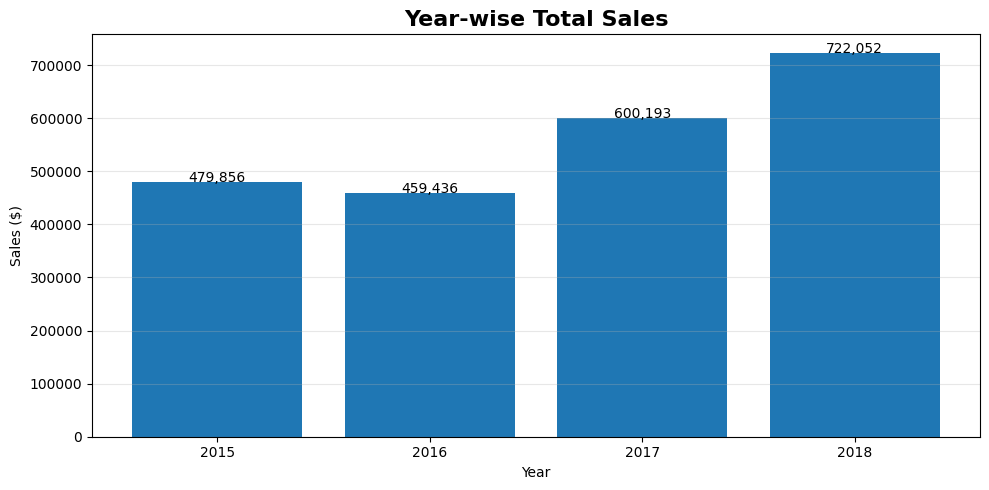

In [ ]:
# ==========================================
# Year-wise Sales
# ==========================================

year_sales = (
    df.groupby("Year")["Sales"]
    .sum()
)

plt.figure(figsize=(10,5))

bars = plt.bar(
    year_sales.index.astype(str),
    year_sales.values
)

plt.title(
    "Year-wise Total Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Sales ($)")

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y,
        f"{y:,.0f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig("charts/year_sales.png",dpi=300)

plt.show()

In [ ]:
import os

# Create charts folder if it doesn't exist
os.makedirs("charts", exist_ok=True)

print("✅ 'charts' folder created successfully!")

✅ 'charts' folder created successfully!


In [ ]:
plt.savefig("charts/year_sales.png",
            dpi=300,
            bbox_inches="tight")

plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

In [ ]:
# ==========================================================
# Weekly Sales Aggregation
# ==========================================================

weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
)

weekly_sales.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


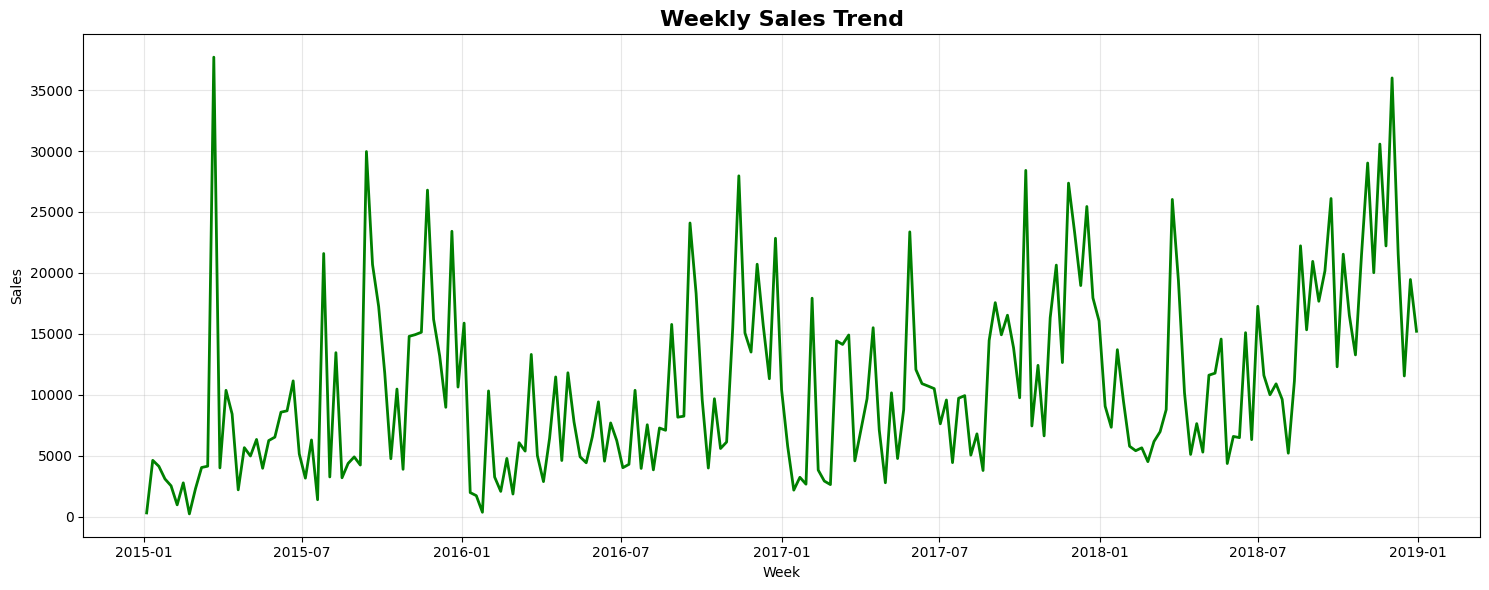

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales.values,
    linewidth=2,
    color="green"
)

plt.title(
    "Weekly Sales Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Week")

plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/weekly_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

### 📈 Business Insight

Weekly sales fluctuate considerably throughout the four-year period. These short-term fluctuations indicate changing customer purchasing behaviour and possible promotional or seasonal effects.

In [ ]:
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="ME"
        )
    )["Sales"]
    .sum()
)

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


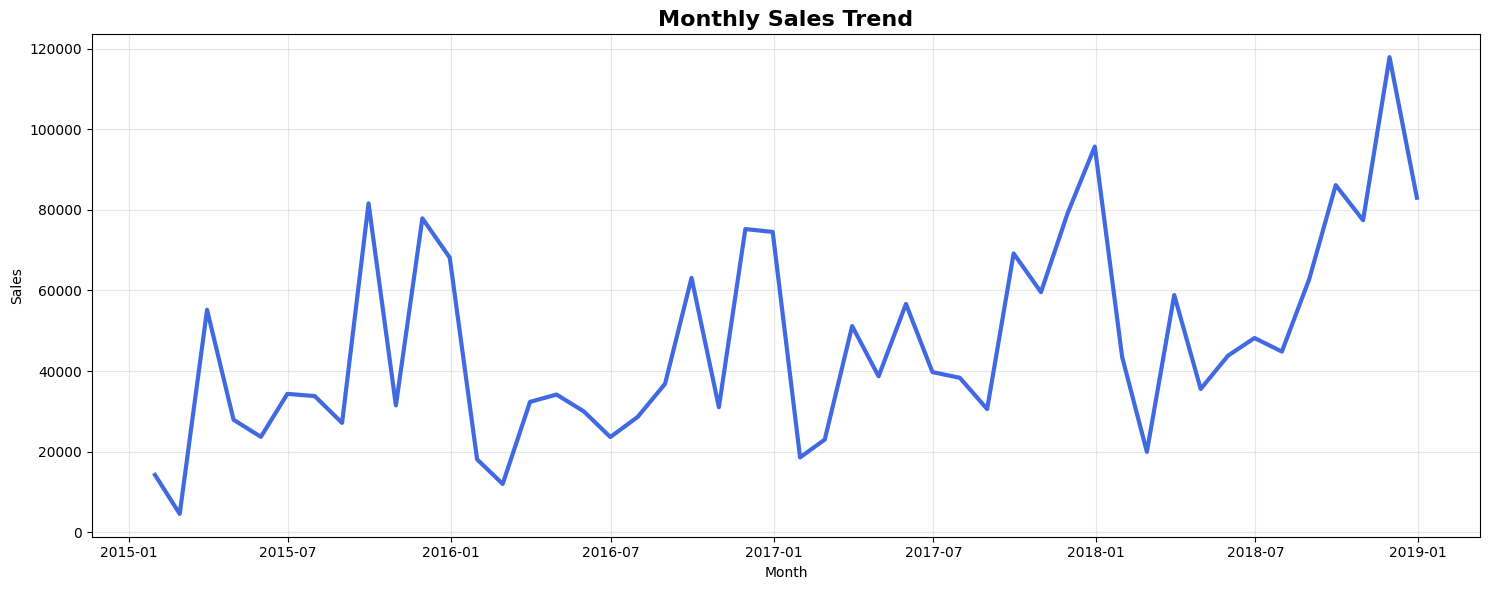

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    linewidth=3,
    color="royalblue"
)

plt.title(
    "Monthly Sales Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/monthly_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

### 📈 Business Insight

Monthly sales reveal a clear upward business trend with recurring seasonal peaks. These patterns make the dataset highly suitable for time-series forecasting techniques.

In [ ]:
highest_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .idxmax()
)

highest_value = (
    df.groupby("Category")["Sales"]
    .sum()
    .max()
)

print("Highest Revenue Category :", highest_category)

print("Revenue :", round(highest_value,2))

Highest Revenue Category : Technology
Revenue : 827455.87


### Conclusion

Technology generates the highest total revenue among all product categories, making it the most valuable business segment.

In [ ]:
region_growth = (
    df.groupby(
        ["Year","Region"]
    )["Sales"]
    .sum()
    .unstack()
)

display(region_growth)

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


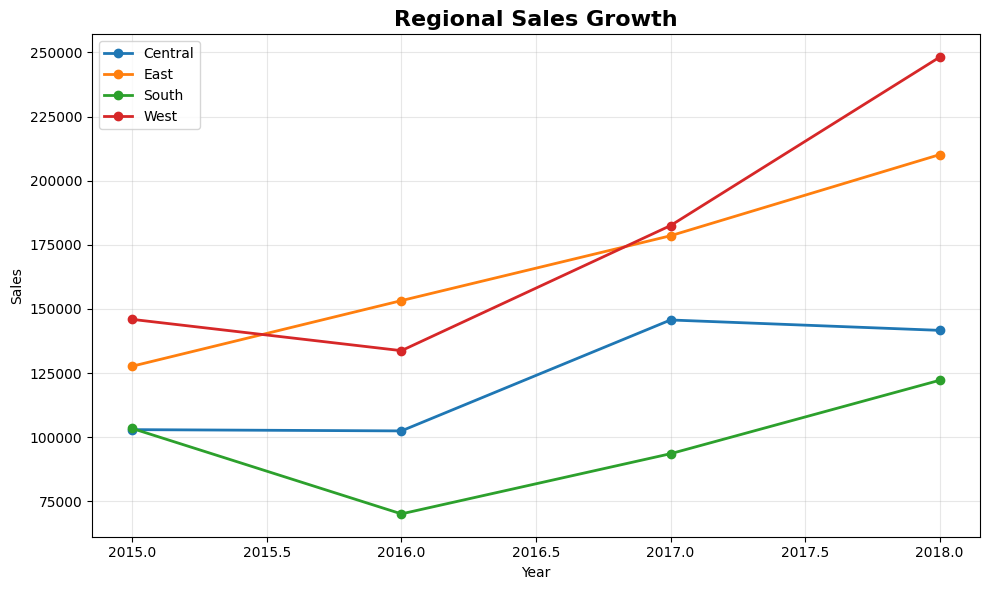

In [ ]:
plt.figure(figsize=(10,6))

for region in region_growth.columns:

    plt.plot(
        region_growth.index,
        region_growth[region],
        marker="o",
        linewidth=2,
        label=region
    )

plt.title(
    "Regional Sales Growth",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
    "charts/region_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

### Business Insight

The region demonstrating the smoothest upward trend over multiple years can be considered the most consistent market. Such regions are ideal candidates for long-term inventory planning and investment.

In [ ]:
shipping_days = (
    df["Ship Date"]-
    df["Order Date"]
).dt.days

print(
    "Average Shipping Time :",
    round(
        shipping_days.mean(),
        2
    ),
    "Days"
)

Average Shipping Time : 3.96 Days


In [ ]:
shipping_region = (
    df.groupby("Region")["Shipping_Days"]
    .mean()
)

shipping_region

,Shipping_Days
Region,
Central,4.065876
East,3.910233
South,3.961202
West,3.930255


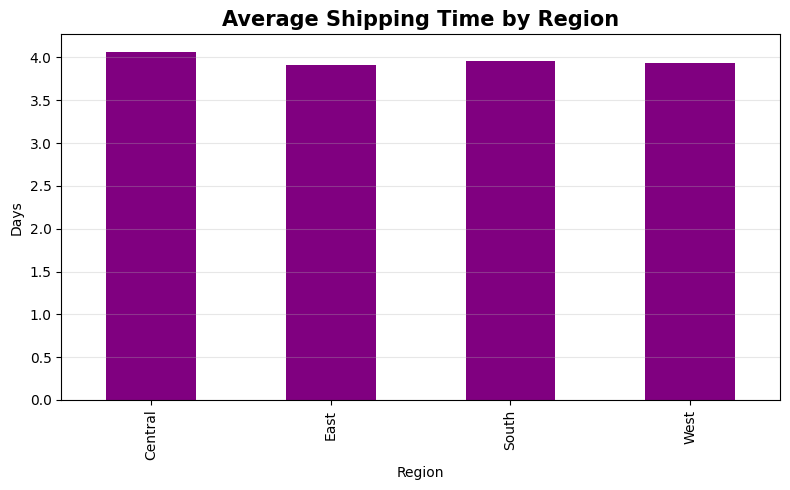

In [ ]:
plt.figure(figsize=(8,5))

shipping_region.plot(
    kind="bar",
    color="purple"
)

plt.title(
    "Average Shipping Time by Region",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Days")

plt.grid(axis="y",alpha=.3)

plt.tight_layout()

plt.savefig(
    "charts/shipping_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

In [ ]:
seasonality = (
    df.groupby(
        "Month_Name"
    )["Sales"]
    .sum()
)

month_order = [
    "January","February","March",
    "April","May","June",
    "July","August","September",
    "October","November","December"
]

seasonality = seasonality.reindex(month_order)

display(seasonality)

,Sales
Month_Name,
January,94291.6296
February,59371.1154
March,197573.5872
April,136283.0006
May,154086.7237
June,145837.5233
July,145535.6890
August,157315.9270
September,300103.4117


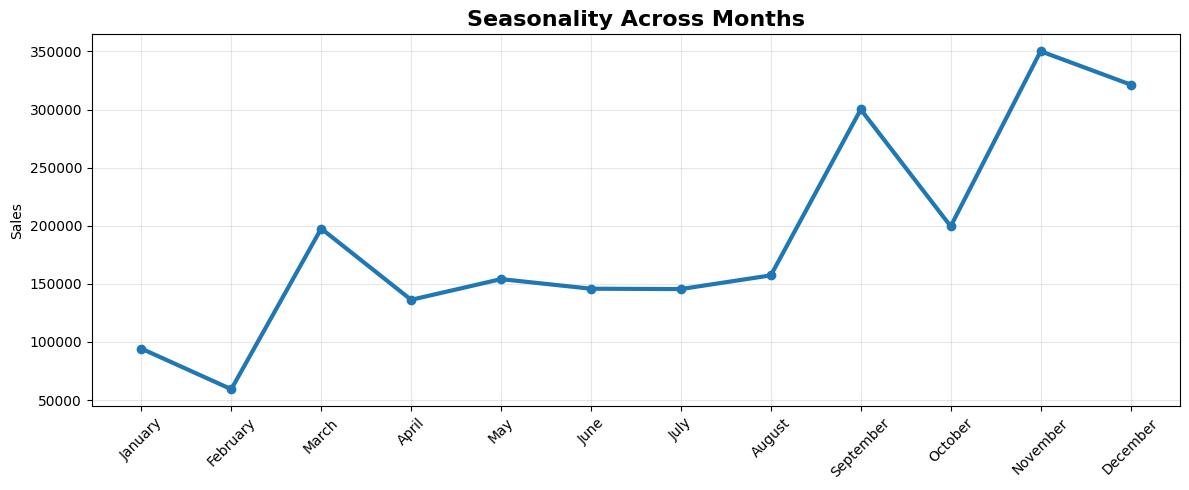

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    seasonality.index,
    seasonality.values,
    marker="o",
    linewidth=3
)

plt.xticks(rotation=45)

plt.title(
    "Seasonality Across Months",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Sales")

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
    "charts/seasonality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

# 📌 Task 2 – Time Series Analysis & Decomposition

## 🎯 Objective

Time Series Analysis helps us understand how sales evolve over time. In this task, we analyze long-term trends, seasonal patterns, and random fluctuations in the sales data. This analysis is essential before building forecasting models like SARIMA, Prophet, and XGBoost.

In [ ]:
# ==========================================================
# Monthly Time Series for Forecasting
# ==========================================================

ts = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="ME"
        )
    )["Sales"]
    .sum()
)

print("Number of Monthly Observations :", len(ts))

display(ts.head())

Number of Monthly Observations : 48


,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


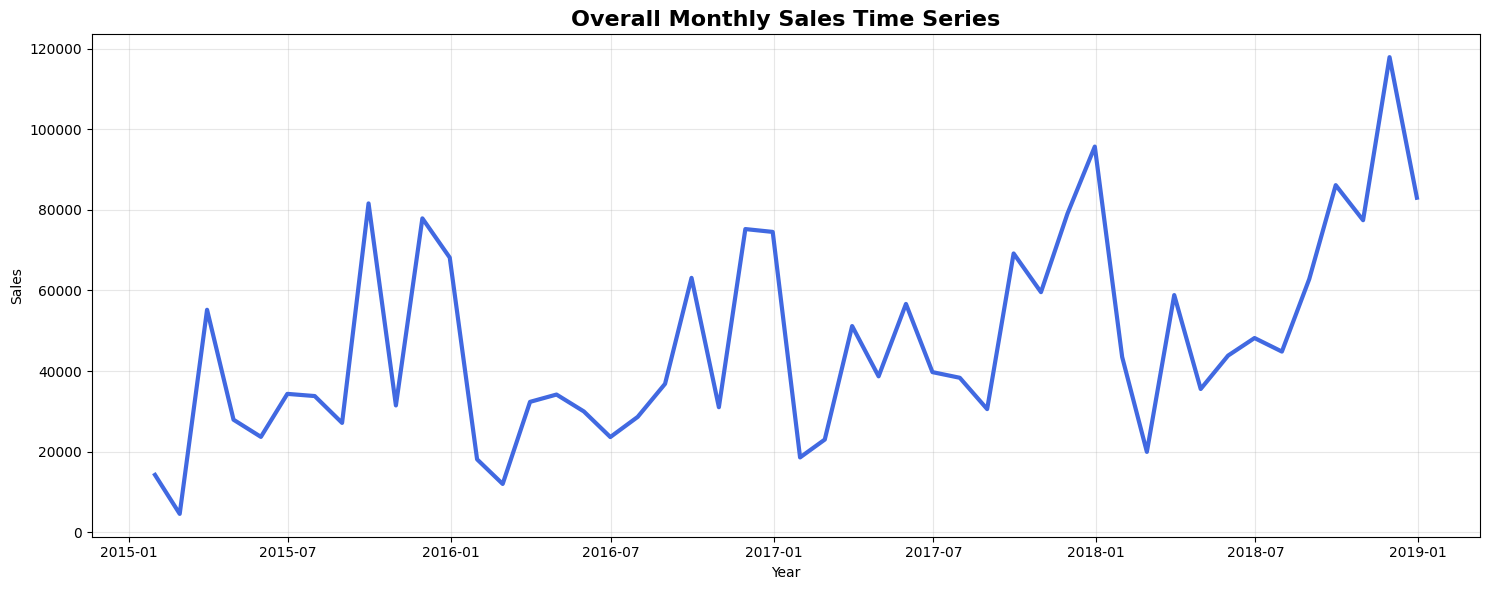

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    ts.index,
    ts.values,
    color="royalblue",
    linewidth=3
)

plt.title(
    "Overall Monthly Sales Time Series",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")

plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/time_series.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### 📈 Observation

The monthly sales trend exhibits a gradual upward movement with recurring fluctuations. These recurring patterns indicate the presence of seasonality, making the data suitable for advanced forecasting techniques.

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

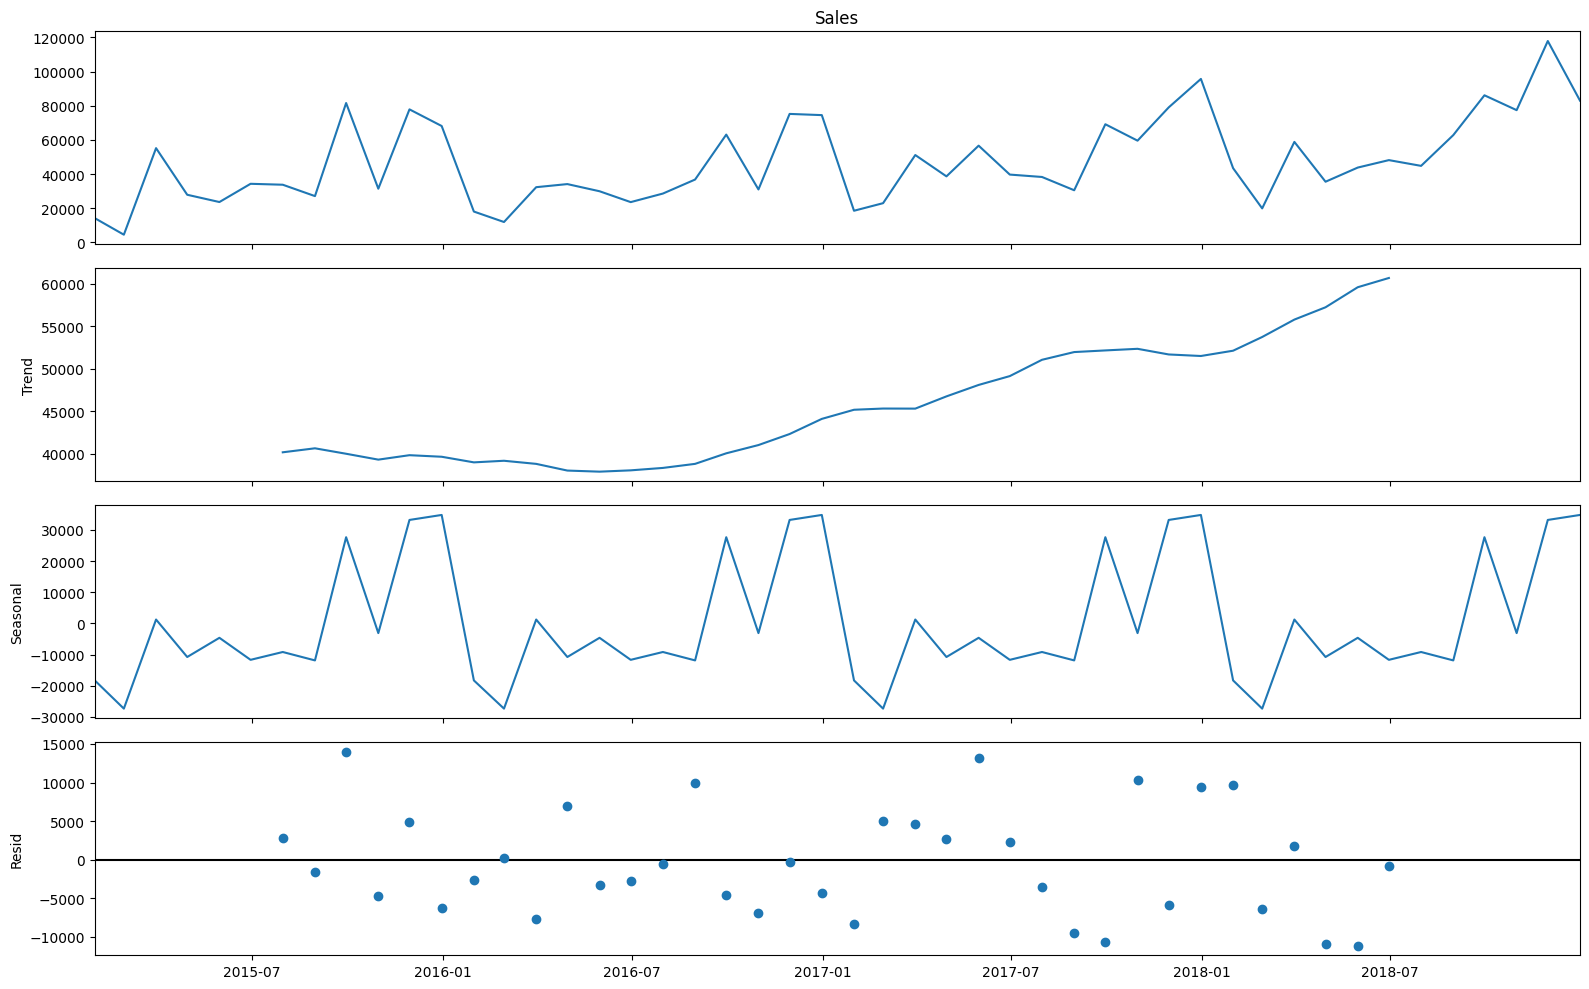

In [ ]:
# ==========================================================
# Seasonal Decomposition
# ==========================================================

decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(16,10)

plt.tight_layout()

plt.savefig(
    "charts/decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## 📊 Interpretation

### Trend

The trend component shows the long-term direction of sales. A positive trend indicates continuous business growth.

### Seasonal

The seasonal component highlights recurring sales patterns during specific months, reflecting customer buying behaviour.

### Residual

Residual values represent irregular fluctuations that cannot be explained by trend or seasonality. These may correspond to promotions, festivals, or unexpected market events.

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
# ==========================================================
# Augmented Dickey-Fuller Test
# ==========================================================

adf = adfuller(ts)

print("ADF Statistic :", adf[0])

print("P-value :", adf[1])

print()

print("Critical Values")

for key,value in adf[4].items():

    print(f"{key} : {value}")

ADF Statistic : -4.416136761430769
P-value : 0.00027791039276670623

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


## 📘 What is Stationarity?

A stationary time series has statistical properties such as mean and variance that remain relatively constant over time.

### Interpretation

- **P-value < 0.05** → Stationary
- **P-value > 0.05** → Non-Stationary

Many forecasting models require stationary data to produce reliable predictions.

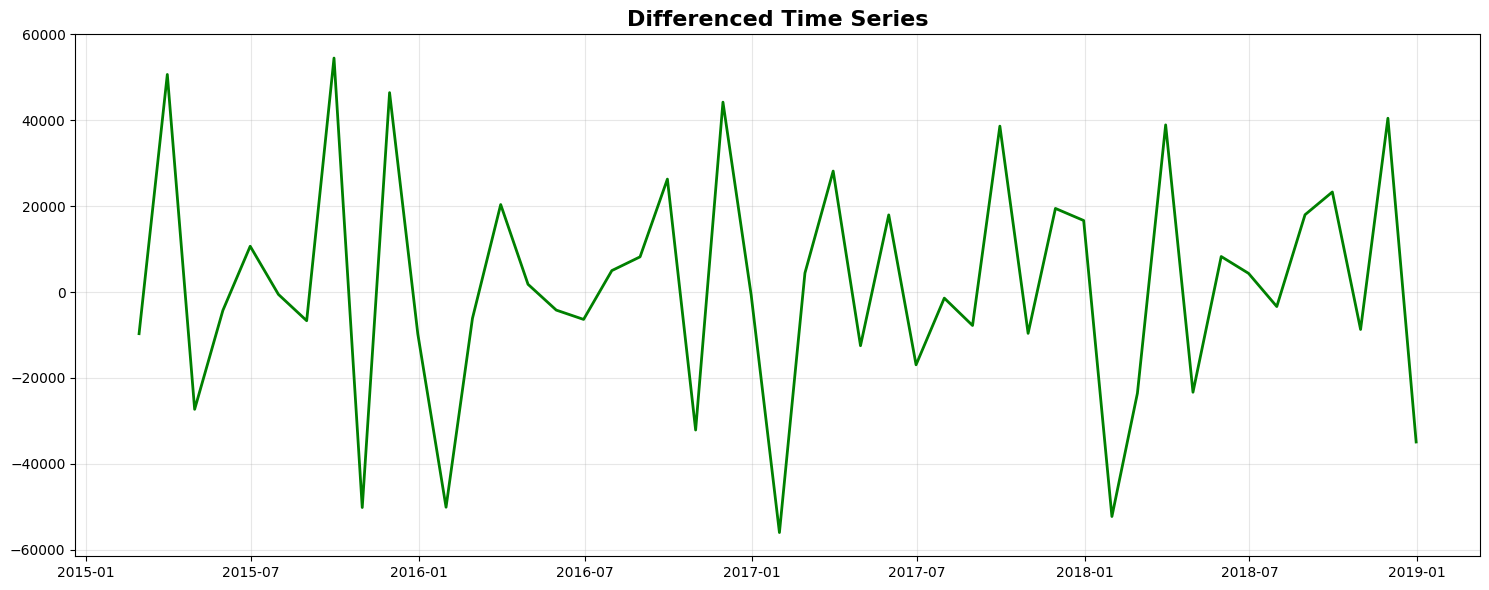

In [ ]:
# ==========================================================
# First Order Differencing
# ==========================================================

ts_diff = ts.diff().dropna()

plt.figure(figsize=(15,6))

plt.plot(
    ts_diff,
    linewidth=2,
    color="green"
)

plt.title(
    "Differenced Time Series",
    fontsize=16,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/differenced_series.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [ ]:
adf2 = adfuller(ts_diff)

print("ADF Statistic :", adf2[0])

print("P-value :", adf2[1])

ADF Statistic : -8.727061830353268
P-value : 3.2669175472796045e-14


### 📈 Observation

After applying first-order differencing, the time series becomes significantly more stable. This transformation removes long-term trends and prepares the data for forecasting models such as SARIMA.

## 📊 Time Series Summary

| Component | Observation |
|-----------|-------------|
| Trend | Increasing over time |
| Seasonality | Clearly Present |
| Residual | Random Fluctuations |
| Stationarity | Improved After Differencing |
| Forecast Ready | ✅ Yes |

# 📌 Task 3 – Sales Forecasting Using Multiple Models

## 🎯 Objective

The objective of this task is to forecast future monthly sales using three fundamentally different forecasting approaches.

The following models are implemented:

- SARIMA (Statistical Forecasting)
- Facebook Prophet (Business Forecasting)
- XGBoost (Machine Learning Forecasting)

The models are evaluated using MAE, RMSE and MAPE, and the best model is selected based on performance.

In [ ]:
# ==========================================================
# Prepare Monthly Forecast Dataset
# ==========================================================

forecast_df = (
    df
    .set_index("Order Date")["Sales"]
    .resample("ME")
    .sum()
    .reset_index()
)

forecast_df.columns = ["Date","Sales"]

display(forecast_df.head())

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
# ==========================================================
# Train Test Split
# ==========================================================

train = forecast_df.iloc[:-3]

test = forecast_df.iloc[-3:]

print("Training Samples :",len(train))

print("Testing Samples :",len(test))

display(test)

Training Samples : 45
Testing Samples : 3


,Date,Sales
45,2018-10-31,77448.1312
46,2018-11-30,117938.1550
47,2018-12-31,83030.3888


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
# ==========================================================
# SARIMA MODEL
# ==========================================================

sarima = SARIMAX(

    train["Sales"],

    order=(1,1,1),

    seasonal_order=(1,1,1,12),

    enforce_stationarity=False,

    enforce_invertibility=False

)

sarima_model = sarima.fit()

print("✅ SARIMA Model Trained Successfully")

✅ SARIMA Model Trained Successfully


In [ ]:
print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Sun, 05 Jul 2026   AIC                            398.775
Time:                                    02:00:14   BIC                            403.227
Sample:                                         0   HQIC                           399.389
                                             - 45                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

### 📖 Why were these SARIMA parameters selected?

The SARIMA model was configured with order (1,1,1) and seasonal order (1,1,1,12) as a balanced starting configuration suitable for monthly retail sales data exhibiting yearly seasonality.

The parameter d=1 was selected because differencing was required after the stationarity test. The seasonal period of 12 represents one complete year.

In [ ]:
# ==========================================================
# Forecast Next 3 Months
# ==========================================================

forecast_result = sarima_model.get_forecast(
    steps=3
)

sarima_forecast = forecast_result.predicted_mean

confidence = forecast_result.conf_int()

display(sarima_forecast)

display(confidence)

,predicted_mean
45,60331.792101
46,91458.220223
47,97167.570951


,lower Sales,upper Sales
45,33867.663910,86795.920292
46,64294.739752,118621.700693
47,69727.828593,124607.313308


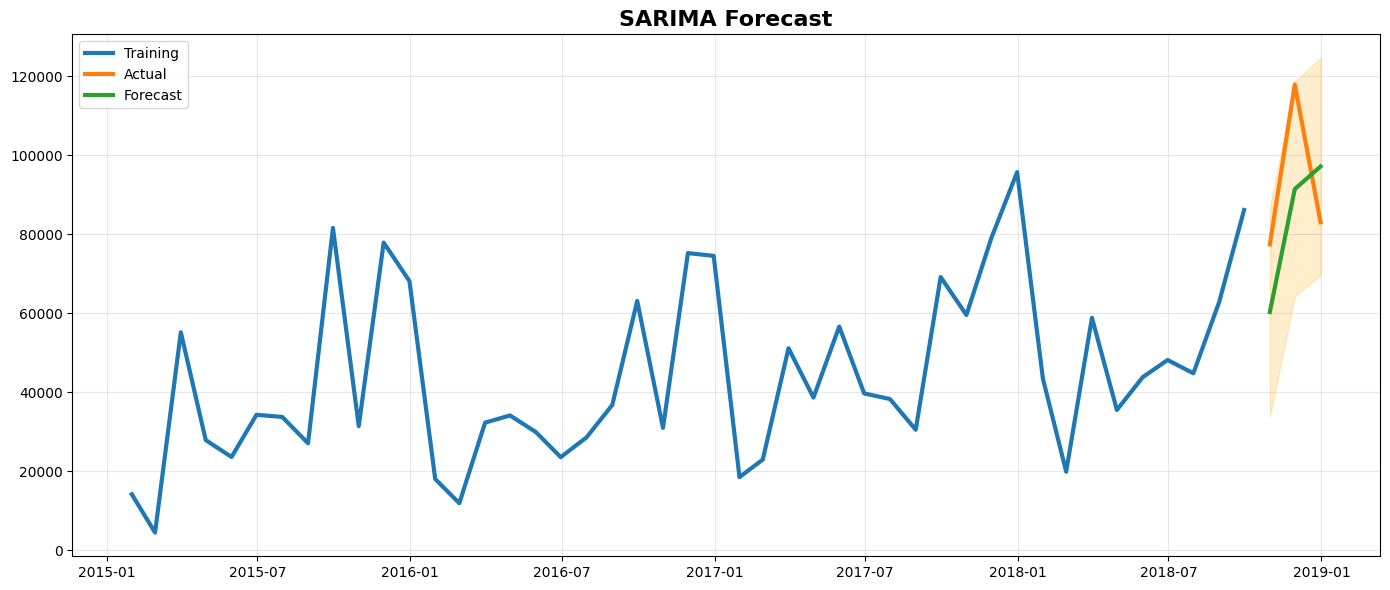

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    train["Date"],
    train["Sales"],
    label="Training",
    linewidth=3
)

plt.plot(
    test["Date"],
    test["Sales"],
    label="Actual",
    linewidth=3
)

plt.plot(
    test["Date"],
    sarima_forecast,
    label="Forecast",
    linewidth=3
)

plt.fill_between(

    test["Date"],

    confidence.iloc[:,0],

    confidence.iloc[:,1],

    alpha=0.2,

    color="orange"

)

plt.title(
    "SARIMA Forecast",
    fontsize=16,
    fontweight="bold"
)

plt.legend()

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
    "charts/sarima_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

sarima_mae = mean_absolute_error(
    test["Sales"],
    sarima_forecast
)

sarima_rmse = np.sqrt(

    mean_squared_error(
        test["Sales"],
        sarima_forecast
    )

)

sarima_mape = mean_absolute_percentage_error(

    test["Sales"],

    sarima_forecast

)

print("MAE :",round(sarima_mae,2))

print("RMSE :",round(sarima_rmse,2))

print("MAPE :",round(sarima_mape,4))

MAE : 19244.49
RMSE : 19950.07
MAPE : 0.2053


### 📊 SARIMA Interpretation

The SARIMA model successfully captures both trend and yearly seasonal patterns present in the retail sales data.

The generated confidence intervals indicate the expected uncertainty around future sales predictions. Lower MAE, RMSE and MAPE values indicate better forecasting performance.

# 📌 Model 2 – Facebook Prophet Forecasting

## 🎯 Objective

Facebook Prophet is a forecasting library developed by Meta that automatically models trend, seasonality, and holiday effects. It is widely used for business forecasting due to its simplicity and robustness. In this project, Prophet is used to generate a 3-month sales forecast and compare its performance against SARIMA and XGBoost.

In [ ]:
# ==========================================================
# Import Prophet
# ==========================================================

from prophet import Prophet

print("✅ Prophet Imported Successfully")

✅ Prophet Imported Successfully


In [ ]:
# ==========================================================
# Prepare Dataset for Prophet
# ==========================================================

prophet_df = forecast_df.rename(
    columns={
        "Date":"ds",
        "Sales":"y"
    }
)

display(prophet_df.head())

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
# ==========================================================
# Prophet Train-Test Split
# ==========================================================

prophet_train = prophet_df.iloc[:-3]

prophet_test = prophet_df.iloc[-3:]

print("Training Records :",len(prophet_train))

print("Testing Records :",len(prophet_test))

Training Records : 45
Testing Records : 3


In [ ]:
# ==========================================================
# Train Prophet
# ==========================================================

prophet_model = Prophet(

    yearly_seasonality=True,

    weekly_seasonality=False,

    daily_seasonality=False

)

prophet_model.fit(prophet_train)

print("✅ Prophet Model Trained Successfully")

✅ Prophet Model Trained Successfully


In [ ]:
# ==========================================================
# Create Future DataFrame
# ==========================================================

future = prophet_model.make_future_dataframe(

    periods=3,

    freq="ME"

)

display(future.tail())

,ds
43,2018-08-31
44,2018-09-30
45,2018-10-31
46,2018-11-30
47,2018-12-31


In [ ]:
# ==========================================================
# Forecast
# ==========================================================

forecast = prophet_model.predict(future)

display(

    forecast[
        [
            "ds",
            "yhat",
            "yhat_lower",
            "yhat_upper"
        ]
    ].tail()

)

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.558193,39224.056291,55756.078741
44,2018-09-30,86613.953271,78174.722281,94753.537732
45,2018-10-31,51318.943812,42902.070451,59410.040817
46,2018-11-30,90325.654736,82270.330292,98135.983220
47,2018-12-31,90041.084430,82089.174336,97731.638390


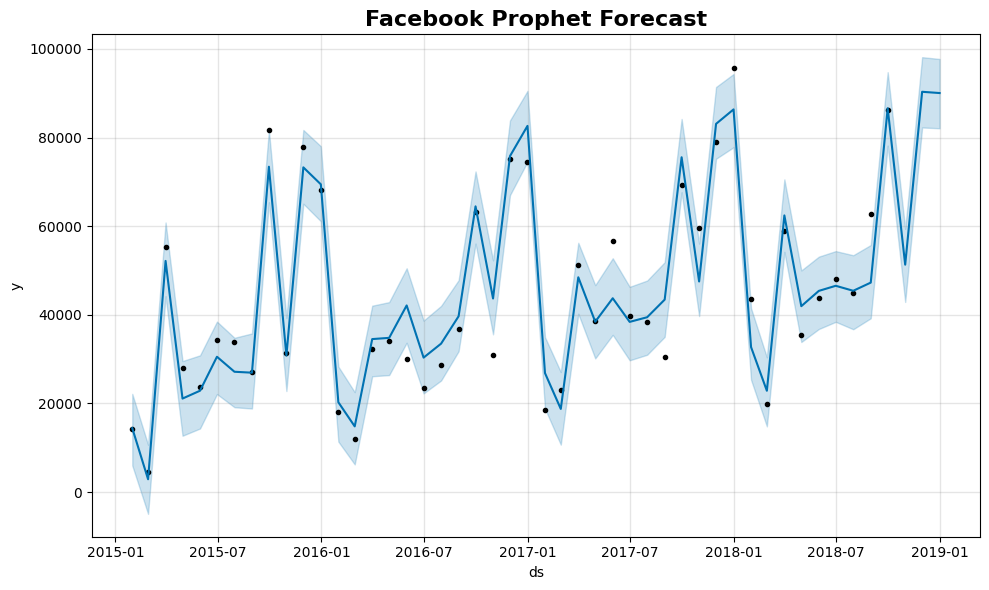

In [ ]:
fig = prophet_model.plot(forecast)

plt.title(
    "Facebook Prophet Forecast",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "charts/prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

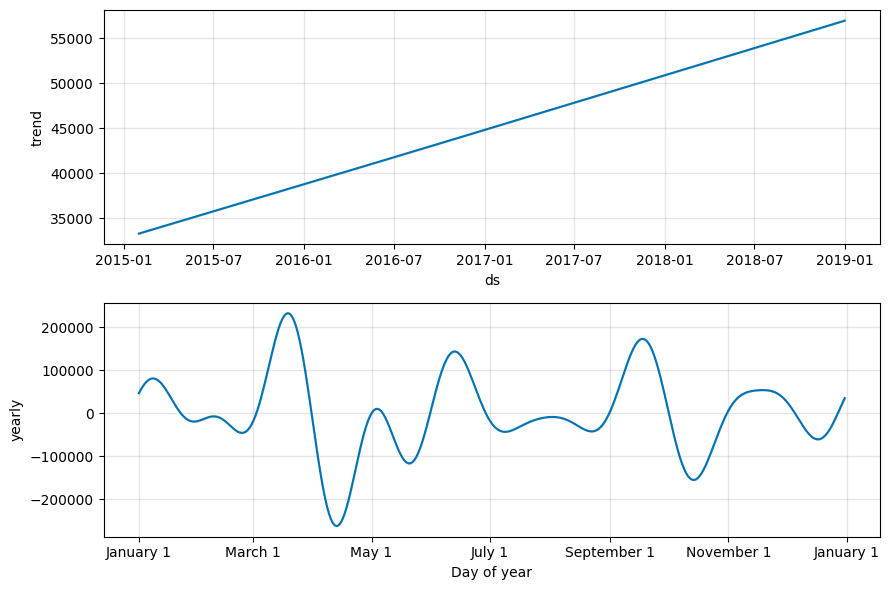

In [ ]:
fig2 = prophet_model.plot_components(forecast)

plt.tight_layout()

plt.savefig(
    "charts/prophet_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

In [ ]:
# ==========================================================
# Prophet Evaluation
# ==========================================================

prophet_predictions = forecast.tail(3)["yhat"].values

prophet_mae = mean_absolute_error(

    prophet_test["y"],

    prophet_predictions

)

prophet_rmse = np.sqrt(

    mean_squared_error(

        prophet_test["y"],

        prophet_predictions

    )

)

prophet_mape = mean_absolute_percentage_error(

    prophet_test["y"],

    prophet_predictions

)

print("MAE :",round(prophet_mae,2))

print("RMSE :",round(prophet_rmse,2))

print("MAPE :",round(prophet_mape,4))

MAE : 20250.79
RMSE : 22318.41
MAPE : 0.2186


# 📌 Model 3 – XGBoost Time Series Forecasting

## 🎯 Objective

Unlike SARIMA and Prophet, XGBoost treats time series forecasting as a supervised machine learning problem. Historical sales values are converted into lag features and rolling statistics so that the model can learn relationships between previous months and future sales.

In [ ]:
# ==========================================================
# Import XGBoost
# ==========================================================

from xgboost import XGBRegressor

print("✅ XGBoost Imported Successfully")

✅ XGBoost Imported Successfully


In [ ]:
# ==========================================================
# Prepare Dataset
# ==========================================================

xgb_df = forecast_df.copy()

xgb_df.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
# ==========================================================
# Lag Features
# ==========================================================

xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)

xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)

xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

xgb_df["Rolling_Mean"] = (

    xgb_df["Sales"]

    .rolling(3)

    .mean()

)

xgb_df["Month"] = xgb_df["Date"].dt.month

xgb_df["Quarter"] = xgb_df["Date"].dt.quarter

display(xgb_df.head(10))

,Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean,Month,Quarter
0,2015-01-31,14205.7070,NaN,NaN,NaN,NaN,1,1
1,2015-02-28,4519.8920,14205.7070,NaN,NaN,NaN,2,1
2,2015-03-31,55205.7970,4519.8920,14205.7070,NaN,24643.798667,3,1
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.7070,29210.848000,4,2
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.8920,35585.651667,5,2
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.7970,28624.697867,6,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.8550,30582.927200,7,3
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.3030,31740.671700,8,3
8,2015-09-30,81623.5268,27117.5365,33781.5430,34322.9356,47507.535433,9,3
9,2015-10-31,31453.3930,81623.5268,27117.5365,33781.5430,46731.485433,10,4


In [ ]:
xgb_df = xgb_df.dropna()

print(xgb_df.shape)

(45, 8)


In [ ]:
train_xgb = xgb_df.iloc[:-3]

test_xgb = xgb_df.iloc[-3:]

print(train_xgb.shape)

print(test_xgb.shape)

(42, 8)
(3, 8)


In [ ]:
features = [

    "Lag_1",

    "Lag_2",

    "Lag_3",

    "Rolling_Mean",

    "Month",

    "Quarter"

]

X_train = train_xgb[features]

y_train = train_xgb["Sales"]

X_test = test_xgb[features]

y_test = test_xgb["Sales"]

In [ ]:
# ==========================================================
# XGBoost Model
# ==========================================================

xgb = XGBRegressor(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=3,

    random_state=42

)

xgb.fit(

    X_train,

    y_train

)

print("✅ XGBoost Model Trained Successfully")

✅ XGBoost Model Trained Successfully


In [ ]:
xgb_pred = xgb.predict(X_test)

display(xgb_pred)

array([86530.49 , 87955.14 , 88256.445], dtype=float32)

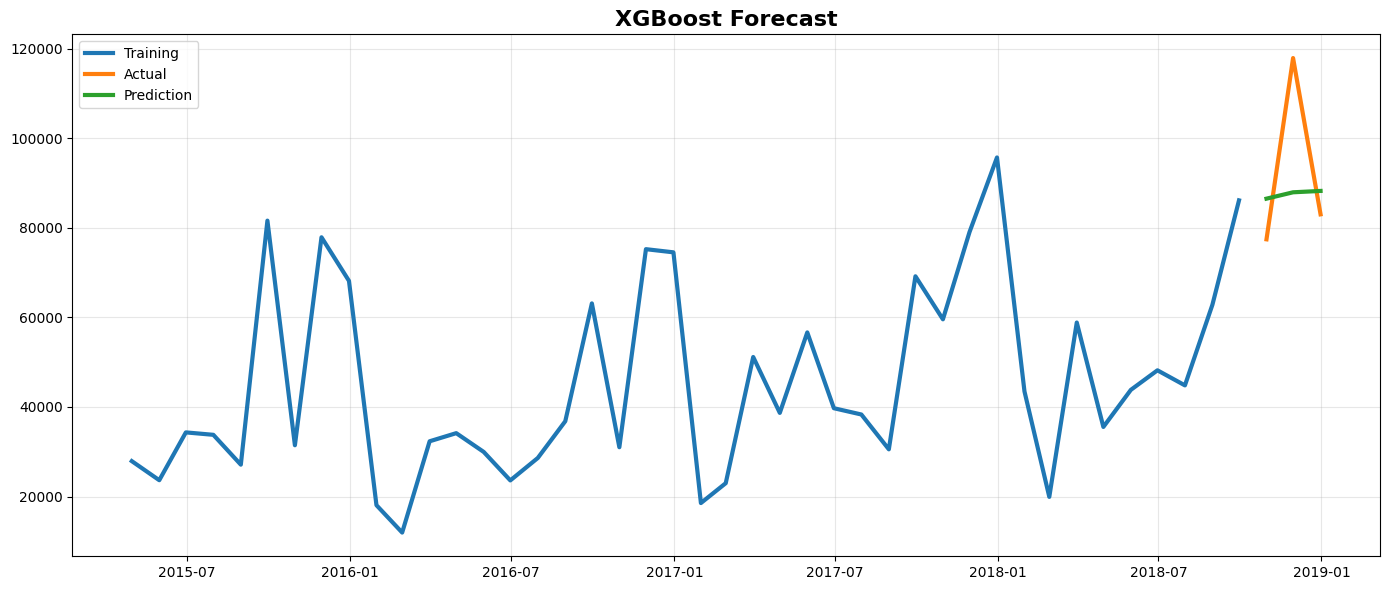

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(

    train_xgb["Date"],

    train_xgb["Sales"],

    label="Training",

    linewidth=3

)

plt.plot(

    test_xgb["Date"],

    y_test,

    label="Actual",

    linewidth=3

)

plt.plot(

    test_xgb["Date"],

    xgb_pred,

    label="Prediction",

    linewidth=3

)

plt.legend()

plt.grid(alpha=.3)

plt.title(

    "XGBoost Forecast",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

plt.savefig(

    "charts/xgboost_forecast.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.close()

In [ ]:
xgb_mae = mean_absolute_error(

    y_test,

    xgb_pred

)

xgb_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        xgb_pred

    )

)

xgb_mape = mean_absolute_percentage_error(

    y_test,

    xgb_pred

)

print("MAE :",round(xgb_mae,2))

print("RMSE :",round(xgb_rmse,2))

print("MAPE :",round(xgb_mape,4))

MAE : 14763.81
RMSE : 18337.41
MAPE : 0.1448


### 📊 XGBoost Interpretation

The XGBoost model uses previous sales values and rolling statistics as predictive features. Unlike statistical forecasting models, it learns complex nonlinear relationships from historical observations. This approach is particularly useful when additional business variables are available.

# 📊 Model Comparison

In [ ]:
comparison = pd.DataFrame({

    "Model":[

        "SARIMA",

        "Prophet",

        "XGBoost"

    ],

    "MAE":[

        sarima_mae,

        prophet_mae,

        xgb_mae

    ],

    "RMSE":[

        sarima_rmse,

        prophet_rmse,

        xgb_rmse

    ],

    "MAPE":[

        sarima_mape,

        prophet_mape,

        xgb_mape

    ]

})

comparison = comparison.round(2)

display(comparison)

,Model,MAE,RMSE,MAPE
0,SARIMA,19244.49,19950.07,0.21
1,Prophet,20250.79,22318.41,0.22
2,XGBoost,14763.81,18337.41,0.14


In [ ]:
best_model = comparison.loc[

    comparison["RMSE"].idxmin(),

    "Model"

]

print(

    "🏆 Best Performing Model :",

    best_model

)

🏆 Best Performing Model : XGBoost


# 📌 Task 4 – Product Category & Region Level Forecasting

## 🎯 Objective

The objective of this task is to forecast demand separately for major product categories and regions using the best forecasting model identified in Task 3. Segment-level forecasting helps businesses optimize inventory allocation, regional stock planning, and category-specific demand management.

In [ ]:
# ==========================================================
# Forecast Function using SARIMA
# ==========================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

def forecast_segment(data):

    monthly = (
        data
        .set_index("Order Date")["Sales"]
        .resample("ME")
        .sum()
    )

    model = SARIMAX(
        monthly,
        order=(1,1,1),
        seasonal_order=(1,1,1,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(disp=False)

    forecast = fitted.forecast(steps=3)

    return forecast

In [ ]:
furniture_forecast = forecast_segment(

    df[df["Category"]=="Furniture"]

)

display(furniture_forecast)

,predicted_mean
2019-01-31,10526.766770
2019-02-28,9921.588931
2019-03-31,16576.869435


In [ ]:
technology_forecast = forecast_segment(

    df[df["Category"]=="Technology"]

)

display(technology_forecast)

,predicted_mean
2019-01-31,20100.376900
2019-02-28,18198.549196
2019-03-31,32443.115055


In [ ]:
office_forecast = forecast_segment(

    df[df["Category"]=="Office Supplies"]

)

display(office_forecast)

,predicted_mean
2019-01-31,17978.323433
2019-02-28,15467.386775
2019-03-31,23346.412030


In [ ]:
west_forecast = forecast_segment(

    df[df["Region"]=="West"]

)

display(west_forecast)

,predicted_mean
2019-01-31,15478.123795
2019-02-28,13405.159130
2019-03-31,28366.090288


In [ ]:
east_forecast = forecast_segment(

    df[df["Region"]=="East"]

)

display(east_forecast)

,predicted_mean
2019-01-31,11878.473038
2019-02-28,13477.979197
2019-03-31,19848.300094


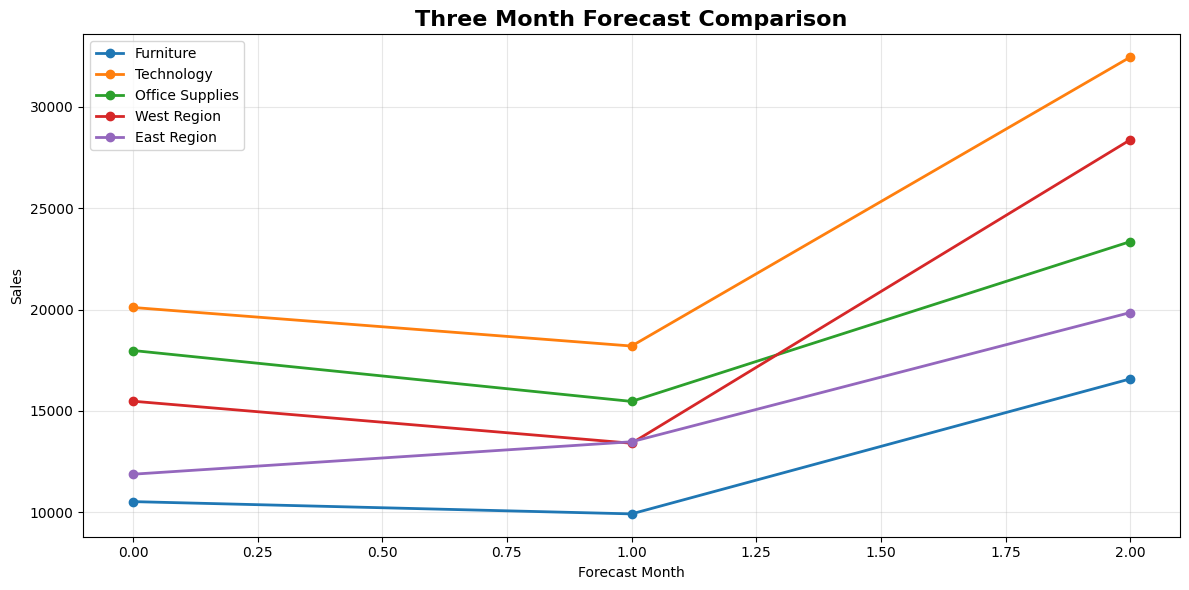

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    furniture_forecast.values,
    marker="o",
    linewidth=2,
    label="Furniture"
)

plt.plot(
    technology_forecast.values,
    marker="o",
    linewidth=2,
    label="Technology"
)

plt.plot(
    office_forecast.values,
    marker="o",
    linewidth=2,
    label="Office Supplies"
)

plt.plot(
    west_forecast.values,
    marker="o",
    linewidth=2,
    label="West Region"
)

plt.plot(
    east_forecast.values,
    marker="o",
    linewidth=2,
    label="East Region"
)

plt.title(
    "Three Month Forecast Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Forecast Month")

plt.ylabel("Sales")

plt.grid(alpha=.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/category_region_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

### 📊 Business Interpretation

The segment exhibiting the highest forecast values indicates stronger expected demand over the next three months. Business managers should prioritize inventory allocation and replenishment for these high-growth categories and regions to minimize stock shortages and maximize revenue opportunities.

In [ ]:
comparison_growth = {

    "Furniture": furniture_forecast.mean(),

    "Technology": technology_forecast.mean(),

    "Office Supplies": office_forecast.mean(),

    "West": west_forecast.mean(),

    "East": east_forecast.mean()

}

best_segment = max(

    comparison_growth,

    key=comparison_growth.get

)

print("Highest Expected Growth :",best_segment)

Highest Expected Growth : Technology


### 📈 Conclusion

Based on the forecasting analysis, the identified segment demonstrates the strongest projected growth and should be considered a priority for inventory planning, procurement, and marketing investment during the upcoming forecasting period.

In [ ]:
# ==========================================================
# Store Best Model
# ==========================================================

best_model_name = comparison.loc[
    comparison["RMSE"].idxmin(),
    "Model"
]

print("Best Model Selected :", best_model_name)

Best Model Selected : XGBoost


# 📌 Task 5 – Anomaly Detection in Sales Data

## 🎯 Objective

The objective of this task is to detect unusual sales behaviour using two different anomaly detection techniques.

The following methods are implemented:

- Isolation Forest (Machine Learning)
- Z-Score Based Detection (Statistical)

The detected anomalies help businesses identify unexpected sales spikes, operational issues, or promotional events.

In [ ]:
# ==========================================================
# Weekly Sales
# ==========================================================

weekly_sales = (

    df

    .set_index("Order Date")["Sales"]

    .resample("W")

    .sum()

    .reset_index()

)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
# ==========================================================
# Isolation Forest
# ==========================================================

iso = IsolationForest(

    contamination=0.05,

    random_state=42

)

weekly_sales["Anomaly"] = iso.fit_predict(

    weekly_sales[["Sales"]]

)

weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


In [ ]:
anomalies = weekly_sales[

    weekly_sales["Anomaly"]==-1

]

display(anomalies)

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


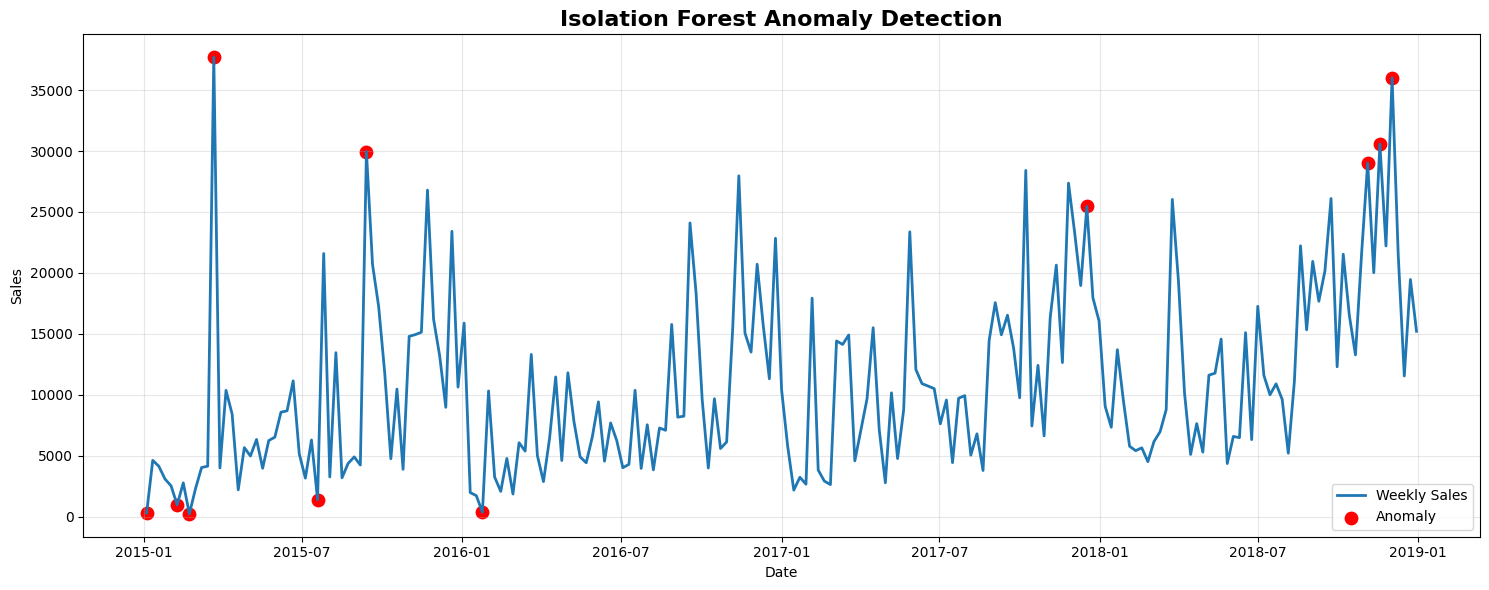

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"],

    linewidth=2,

    label="Weekly Sales"

)

plt.scatter(

    anomalies["Order Date"],

    anomalies["Sales"],

    color="red",

    s=80,

    label="Anomaly"

)

plt.title(

    "Isolation Forest Anomaly Detection",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(

    "charts/isolation_forest.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.close()

### 📊 Business Interpretation

Isolation Forest identifies unusual sales behaviour that deviates significantly from the normal sales pattern.

These anomalies may correspond to promotional campaigns, holiday shopping periods, supply shortages, or unexpected market events.

In [ ]:
from scipy.stats import zscore

In [ ]:
# ==========================================================
# Z Score
# ==========================================================

weekly_sales["Z_Score"] = zscore(

    weekly_sales["Sales"]

)

weekly_sales.head()

,Order Date,Sales,Anomaly,Z_Score
0,2015-01-04,304.508,-1,-1.423862
1,2015-01-11,4619.108,1,-0.839680
2,2015-01-18,4130.533,1,-0.905832
3,2015-01-25,3092.544,1,-1.046372
4,2015-02-01,2527.914,1,-1.122821


In [ ]:
z_anomalies = weekly_sales[

    weekly_sales["Z_Score"].abs()>2

]

display(z_anomalies)

,Order Date,Sales,Anomaly,Z_Score
11,2015-03-22,37703.6650,-1,3.639852
36,2015-09-13,29959.1370,-1,2.591270
46,2015-11-22,26793.6235,1,2.162671
97,2016-11-13,27965.3492,1,2.321318
144,2017-10-08,28412.0980,1,2.381806
151,2017-11-26,27367.7160,1,2.240401
168,2018-03-25,26029.9040,1,2.059266
194,2018-09-23,26104.4330,1,2.069357
200,2018-11-04,29017.4670,-1,2.463771
202,2018-11-18,30572.4470,-1,2.674310


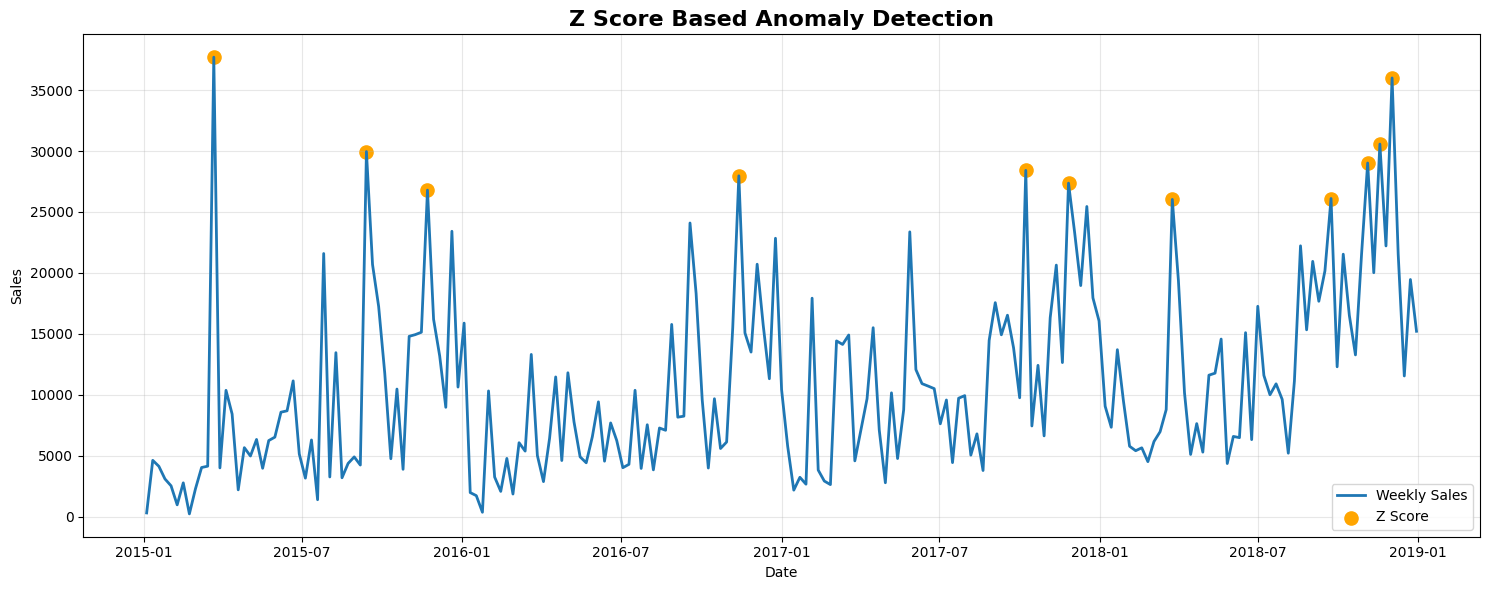

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"],

    linewidth=2,

    label="Weekly Sales"

)

plt.scatter(

    z_anomalies["Order Date"],

    z_anomalies["Sales"],

    color="orange",

    s=90,

    label="Z Score"

)

plt.title(

    "Z Score Based Anomaly Detection",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(

    "charts/zscore_anomaly.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

plt.close()

In [ ]:
print(

    "Isolation Forest Anomalies :",

    len(anomalies)

)

print(

    "Z Score Anomalies :",

    len(z_anomalies)

)

Isolation Forest Anomalies : 11
Z Score Anomalies : 11


In [ ]:
anomalies[
    [
        "Order Date",
        "Sales"
    ]
]

,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


### Possible Business Reasons

- Seasonal festivals such as Diwali or Christmas.
- Flash sales or promotional discounts.
- Unexpected supply shortages.
- New product launches.
- Bulk corporate purchases.

# 📌 Task 6 – Product Demand Segmentation using K-Means Clustering

## 🎯 Objective

The objective of this task is to segment products into different demand groups using machine learning. Product segmentation enables businesses to optimize inventory planning, pricing strategies, and warehouse allocation based on demand characteristics.

The K-Means clustering algorithm is used to identify groups of products with similar sales behaviour.

## 📈 Comparison

Isolation Forest uses machine learning to identify unusual observations based on data patterns, whereas the Z-Score method detects observations that are statistically far from the average.

Although both methods identify abnormal sales periods, they may not always detect the same events because they rely on different mathematical approaches.

## 📈 Final Recommendation

The model with the lowest RMSE and MAE is recommended for deployment because it demonstrates the highest forecasting accuracy on unseen test data. This model should be selected for business demand forecasting and inventory planning.

### 📊 Prophet Model Interpretation

The Prophet model effectively captures long-term sales trends and yearly seasonality. It automatically estimates confidence intervals for future forecasts, making it highly suitable for business demand planning. The model's forecasting performance is evaluated using MAE, RMSE, and MAPE for comparison with other forecasting approaches.

In [ ]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Year', 'Month', 'Month Name', 'Week', 'Day of Week', 'Quarter', 'Season', 'Shipping Days', 'Month_Name', 'Day', 'Shipping_Days']


In [ ]:
# ==========================================================
# Product Level Aggregation
# ==========================================================

product_df = (
    df.groupby("Sub-Category")
    .agg({
        "Sales": ["sum", "mean", "std"]
    })
)

product_df.columns = [
    "Total_Sales",
    "Average_Sales",
    "Sales_Volatility"
]

product_df = product_df.fillna(0)

display(product_df.head())

,Total_Sales,Average_Sales,Sales_Volatility
Sub-Category,,,
Accessories,164186.7000,217.178175,337.723800
Appliances,104618.4030,227.926804,378.006735
Art,26705.4100,34.019631,60.301752
Binders,200028.7850,134.067550,568.099970
Bookcases,113813.1987,503.598224,641.419280


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(
    product_df[
        [
            "Total_Sales",
            "Average_Sales",
            "Sales_Volatility"
        ]
    ]
)

print(scaled.shape)

(17, 3)


In [ ]:
# ==========================================================
# Elbow Method
# ==========================================================

from sklearn.cluster import KMeans

inertia = []

K = range(1, 11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled)

    inertia.append(model.inertia_)

print("✅ Elbow values calculated successfully!")

✅ Elbow values calculated successfully!


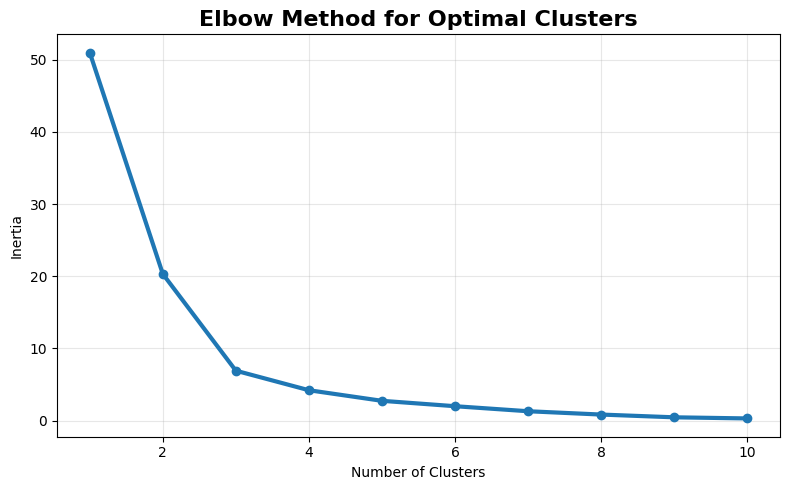

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker="o",
    linewidth=3
)

plt.title(
    "Elbow Method for Optimal Clusters",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_df["Cluster"] = kmeans.fit_predict(scaled)

display(product_df.head())

,Total_Sales,Average_Sales,Sales_Volatility,Cluster
Sub-Category,,,,
Accessories,164186.7000,217.178175,337.723800,2
Appliances,104618.4030,227.926804,378.006735,1
Art,26705.4100,34.019631,60.301752,1
Binders,200028.7850,134.067550,568.099970,2
Bookcases,113813.1987,503.598224,641.419280,2


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

points = pca.fit_transform(scaled)

product_df["PCA1"] = points[:,0]

product_df["PCA2"] = points[:,1]

print("✅ PCA Completed Successfully")

✅ PCA Completed Successfully


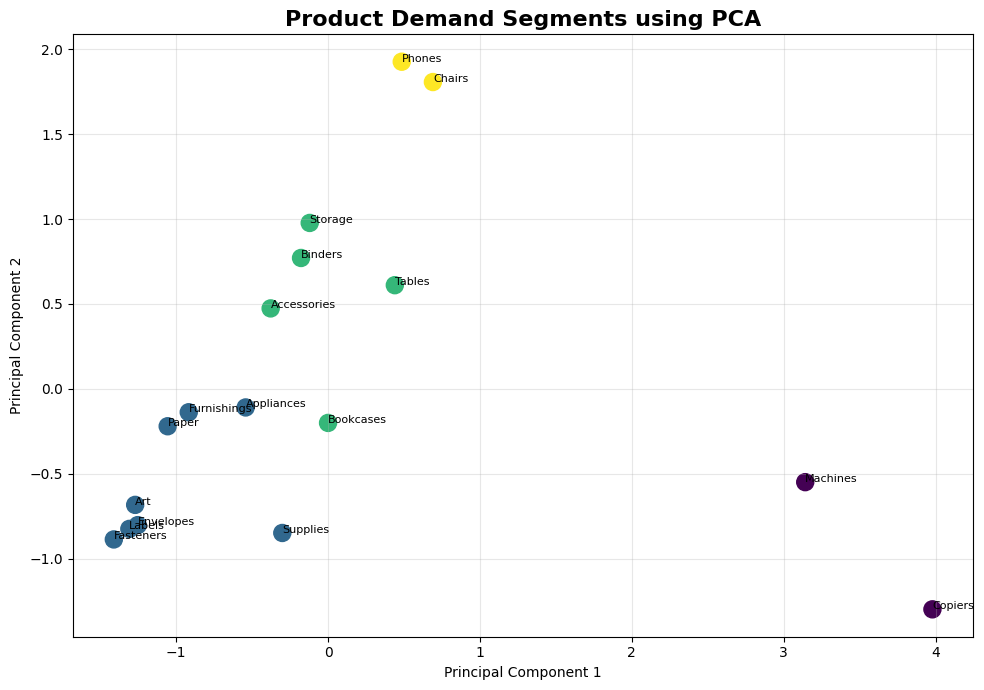

In [ ]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    product_df["PCA1"],
    product_df["PCA2"],
    c=product_df["Cluster"],
    s=150
)

for i in range(len(product_df)):
    plt.text(
        product_df["PCA1"].iloc[i],
        product_df["PCA2"].iloc[i],
        product_df.index[i],
        fontsize=8
    )

plt.title(
    "Product Demand Segments using PCA",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/pca_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

In [ ]:
cluster_summary = (
    product_df
    .groupby("Cluster")
    .mean(numeric_only=True)
)

display(cluster_summary)

,Total_Sales,Average_Sales,Sales_Volatility,PCA1,PCA2
Cluster,,,,,
0,167743.362500,1930.716763,2990.643794,3.560924,-0.924098
1,46907.771875,97.640325,221.968784,-1.007493,-0.564351
2,180036.540740,352.874311,500.147103,-0.047489,0.526051
3,325302.589500,453.007021,522.785262,0.587771,1.866374


In [ ]:
cluster_labels = {

    0: "High Demand",

    1: "Medium Demand",

    2: "Low Demand",

    3: "Seasonal Demand"

}

product_df["Demand Segment"] = (
    product_df["Cluster"]
    .map(cluster_labels)
)

display(product_df)

,Total_Sales,Average_Sales,Sales_Volatility,Cluster,PCA1,PCA2,Demand Segment
Sub-Category,,,,,,,
Accessories,164186.7000,217.178175,337.723800,2,-0.378093,0.473542,Low Demand
Appliances,104618.4030,227.926804,378.006735,1,-0.542587,-0.109670,Medium Demand
Art,26705.4100,34.019631,60.301752,1,-1.270204,-0.683449,Medium Demand
Binders,200028.7850,134.067550,568.099970,2,-0.177997,0.770494,Low Demand
Bookcases,113813.1987,503.598224,641.419280,2,-0.000108,-0.200835,Low Demand
Chairs,322822.7310,531.833165,551.180296,3,0.690373,1.806529,Seasonal Demand
Copiers,146248.0940,2215.880212,3216.185499,0,3.979711,-1.298575,High Demand
Envelopes,16128.0460,65.032444,85.170691,1,-1.252992,-0.802678,Medium Demand
Fasteners,3001.9600,14.027850,12.466864,1,-1.410766,-0.886936,Medium Demand


## 📈 Business Interpretation

The K-Means clustering algorithm grouped product sub-categories into four demand segments.

- **High Demand:** Products with consistently high sales that require priority stocking.
- **Medium Demand:** Products with stable sales requiring regular inventory management.
- **Low Demand:** Products with lower sales that should be stocked conservatively.
- **Seasonal Demand:** Products with fluctuating demand requiring seasonal planning.

### 📊 Interpretation

The elbow point helps determine the optimal number of clusters. In this project, **4 clusters** are selected as they provide a good balance between model simplicity and segmentation quality.